# Análisis exploratorio de variables
### Autor: Diego Sánchez de la Fuente

In [1]:
# Imports necesarios core
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
# Para graficar
from matplotlib import pyplot as plt
import plotly.express as px
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [3]:
# Estadistica
from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp
from scipy.stats import spearmanr
from scipy.stats import kruskal

In [4]:
# Modelados
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

In [5]:
# Refgularizacion de modelos
import sys
from pathlib import Path

# sube desde Prueba/ a project_root/
ROOT = Path.cwd().resolve()

# si el notebook se abre desde Prueba/, subimos un nivel
if (ROOT / "src").exists() is False:
    ROOT = ROOT.parent

# añade project_root al PYTHONPATH de la sesión
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.model_lagrangian import lagrangian_rank

In [6]:
df_tablon = pd.read_parquet("../data/processed/final/tablon_final_v3.parquet")

# Análisis de las variables del tablón

In [7]:
df_tablon.columns

Index(['pub', 'ops_pub_date', 'roi_proxy', 'roi_class', 'ops_n_applicants',
       'ops_n_inventors', 'ops_n_ipc', 'ops_n_cpc', 'ops_ipc_main',
       'family_size_simple', 'family_country_count_simple',
       'family_kinds_count_simple', 'legal_events_count', 'legal_codes_unique',
       'legal_first_date', 'legal_last_date', 'legal_has_grant_like',
       'legal_has_opposition_like', 'ops_pub_date_biblio',
       'ops_n_applicants_biblio', 'ops_n_inventors_biblio', 'ops_n_cpc_biblio',
       'ops_n_ipc_biblio', 'ops_ipc_main_biblio', 'ops_title', 'ops_abstract',
       'biblio_priority_count', 'biblio_priority_date_min',
       'biblio_priority_year', 'biblio_application_date',
       'biblio_application_year', 'biblio_publication_date',
       'biblio_publication_year', 'biblio_kind', 'biblio_title',
       'biblio_abstract', 'party_applicant_count', 'party_inventor_count',
       'party_applicant_country_list', 'party_applicant_country_count',
       'party_applicant_country_main'

In [8]:
# Features a excluir:
EXCLUDE_FEATURES = [
    # Targets
    "roi_proxy",
    "roi_proxy_v2",
    "roi_proxy_v3",
    "cost_proxy_v2",
    "roi_class",

    # Componentes directos del proxy ROI
    "family_size_simple",
    "log_family_size",
    "legal_events_count",
    "legal_codes_unique",
    "tech_breadth_proxy",
]

## Definition of the board variables:

### Identification and basic dates

| Variable                  | Description                                                                                 |
| ------------------------- | ------------------------------------------------------------------------------------------- |
| **`pub`**                 | Unique identifier of the patent publication (primary key of the board).                   |
| **`ops_pub_date`**        | Official publication date according to OPS.                                                |
| **`ops_pub_date_biblio`** | Publication date obtained from the bibliographic block (alternative contrast source).     |
| **`pub_prefix`**          | Publication number prefix (EP, US, WO, CN, etc.), indicates jurisdiction.                 |
| **`pub_year`**            | Year of publication (extracted from the date).                                             |
| **`pub_month`**           | Month of publication (extracted from the date).                                            |
| **`patent_age_days`**     | Patent age in days since publication.                                                      |
| **`patent_age_years`**    | Patent age in years (more interpretable temporal proxy).                                   |

(*) Key temporal variables to analyze maturity, life cycle, and survival effects.

### Target variables (ROI and economic proxies)

| Variable            | Description                                                                                                  |
| ------------------- | ------------------------------------------------------------------------------------------------------------ |
| **`roi_proxy`**     | Initial proxy of the estimated economic return of the patent, constructed from indirect signals.           |
| **`roi_class`**     | Discretization of `roi_proxy` into classes (e.g.: low / medium / high).                                     |
| **`roi_proxy_v2`**  | Second version of the ROI proxy, refined (e.g., different weightings).                                      |
| **`roi_proxy_v3`**  | Third version of the ROI proxy, more robust or conservative.                                                |
| **`roi_class`**     | Classification derived from `roi_proxy_v3`.                                                                  |
| **`cost_proxy_v2`** | Proxy of the economic cost associated with the patent (prosecution, maintenance, complexity).              |

(*) These variables do not represent real ROI, but observable approximations useful for comparative analysis and explanatory models.


### Patent actors (organizational complexity)

| Variable                      | Description                                         |
| ----------------------------- | --------------------------------------------------- |
| **`ops_n_applicants`**        | Number of patent applicants (OPS source).          |
| **`ops_n_inventors`**         | Number of associated inventors.                    |
| **`ops_n_applicants_biblio`** | Number of applicants according to bibliographic data. |
| **`ops_n_inventors_biblio`**  | Number of inventors according to bibliographic data.  |

(*) A higher number of actors is usually associated with:
- more complex projects
- consortia
- higher initial investment

### Technological classification (IPC / CPC)

| Variable                  | Description                                                      |
| ------------------------- | ---------------------------------------------------------------- |
| **`ops_n_ipc`**           | Number of assigned IPC codes.                                    |
| **`ops_n_cpc`**           | Number of assigned CPC codes.                                    |
| **`ops_ipc_main`**        | Main IPC code of the patent.                                     |
| **`ops_n_ipc_biblio`**    | Number of IPC codes according to bibliography.                   |
| **`ops_n_cpc_biblio`**    | Number of CPC codes according to bibliography.                   |
| **`ops_ipc_main_biblio`** | Main IPC according to bibliography.                              |
| **`tech_breadth_proxy`**  | Proxy of technological breadth (diversity of IPC/CPC classes).   |

(*) More codes → greater technological complexity or cross-disciplinarity. The value **`tech_breadth`** is usually associated with higher exploitation potential.


### Patent family (international strategy)

| Variable                          | Description                                                  |
| --------------------------------- | ------------------------------------------------------------ |
| **`family_size_simple`**          | Total number of members in the patent family.               |
| **`family_country_count_simple`** | Number of countries covered by the family.                  |
| **`family_kinds_count_simple`**   | Number of document types (A, B, etc.) in the family.        |
| **`log_family_size`**             | Logarithm of family size (reduces skewness).                 |

(*) Large and multinational families usually imply:
- higher investment
- higher return expectations
- more ambitious commercial strategy

Calculation of the variable: **`log_family_size`**

<code>
    log_family_size = log(1 + family_size_simple)
</code>
<br>
(*) The variable log_family_size is a logarithmic transformation of the patent family size, calculated to reduce distribution skewness and prevent exceptionally large families from dominating the analysis. This transformation is common in bibliometric and econometric studies related to industrial property.


### Legal events and legal status

| Variable                        | Description                                      |
| ------------------------------- | ------------------------------------------------ |
| **`legal_events_count`**        | Total number of recorded legal events.           |
| **`legal_codes_unique`**        | Number of distinct legal codes.                  |
| **`legal_first_date`**          | Date of the first legal event.                   |
| **`legal_last_date`**           | Date of the last legal event.                    |
| **`legal_has_grant_like`**      | Binary indicator of grant or similar event.      |
| **`legal_has_opposition_like`** | Binary indicator of opposition or conflict.      |
| **`legal_missing_dates`**       | Number of legal events without a valid date.     |

(*) More events → “active” or contested patent. Oppositions → possible high value or competitive interest.


### Temporal metrics derived from legal history

| Variable                      | Description                                  |
| ----------------------------- | -------------------------------------------- |
| **`years_since_first_legal`** | Years since the first legal event.           |
| **`years_since_last_legal`**  | Years since the last legal event.            |
| **`alive_span_days`**         | Total legal lifespan in days.                |
| **`alive_years`**             | Total legal lifespan in years.               |
| **`events_per_year`**         | Average frequency of legal events per year.  |
| **`is_active_recent`**        | Indicator of recent legal activity.          |

(*) These variables capture the dynamics and persistence of the patent over time.

(*) **`years_since_first_legal`** and **`years_since_last_legal`** are calculated at the moment of generating the board.

### Text and length (simple semantic signals)

| Variable           | Description                                               |
| ------------------ | --------------------------------------------------------- |
| **`ops_title`**    | Patent title.                                             |
| **`ops_abstract`** | Patent abstract.                                          |
| **`title_len`**    | Title length (number of characters or tokens).            |
| **`abstract_len`** | Abstract length.                                          |

(*) Longer abstracts may reflect greater technical complexity. Useful variables as simple proxies before advanced NLP.

## Identification, bibliography and key dates

| Variable | Description |
|--------|-------------|
| **`biblio_priority_count`** | Number of priorities claimed by the patent. |
| **`biblio_priority_date_min`** | Oldest declared priority date. |
| **`biblio_priority_year`** | Year corresponding to the oldest priority. |
| **`biblio_application_date`** | Official patent application date. |
| **`biblio_application_year`** | Application year. |
| **`biblio_publication_date`** | Official publication date. |
| **`biblio_publication_year`** | Publication year. |
| **`biblio_kind`** | Document *kind* code (A1, B1, etc.), indicates phase and nature of the document. |

(*) These variables allow reconstruction of the **administrative timeline** of the patent and analysis of delays, maturity, and exploitation windows.

---

## Title and abstract (bibliographic source)

| Variable | Description |
|--------|-------------|
| **`biblio_title`** | Patent title according to the bibliographic block. |
| **`biblio_abstract`** | Abstract according to bibliographic data. |

(*) Used as a **baseline contrast source** against full-text when available.

---

## Patent actors (organizational structure)

| Variable | Description |
|--------|-------------|
| **`party_applicant_count`** | Total number of applicants. |
| **`party_inventor_count`** | Total number of inventors. |
| **`party_applicant_country_list`** | List of applicant countries. |
| **`party_applicant_country_count`** | Number of distinct countries represented. |
| **`party_applicant_country_main`** | Main applicant country (dominant heuristic). |
| **`party_applicant_type_main`** | Main applicant type (company, university, individual, etc.). |
| **`party_applicant_type_conf`** | Confidence level of the dominant applicant type. |

(*) A higher number of actors or countries usually correlates with:
- higher initial investment  
- collaborative or consortium-based projects  
- more complex protection strategies  

---

## Full text and semantic availability

| Variable | Description |
|--------|-------------|
| **`text_title`** | Consolidated title for textual analysis. |
| **`text_abstract`** | Consolidated abstract. |
| **`text_claims`** | Full text of the claims. |
| **`text_description`** | Full text of the description. |
| **`text_has_claims`** | Binary indicator of claims availability. |
| **`text_has_description`** | Binary indicator of description availability. |
| **`text_available`** | Indicates whether sufficient text exists for semantic analysis. |

(*) These variables determine whether the patent is **usable for NLP, embeddings, and advanced semantic analysis**.

---

## Text length (technical complexity proxies)

| Variable | Description |
|--------|-------------|
| **`text_len_title`** | Title length. |
| **`text_len_abstract`** | Abstract length. |
| **`text_len_claims`** | Claims length. |
| **`text_len_description`** | Description length. |

(*) Longer texts usually reflect:
- greater technical density  
- greater drafting effort  
- more complex inventions  

These metrics function as **simple proxies prior to NLP**.

---

## Text prepared for embeddings

| Variable | Description |
|--------|-------------|
| **`text_for_embedding`** | Unified and cleaned text used to generate embeddings. |
| **`text_len_embedding`** | Total length of the input text to the embedding model. |

(**) `text_for_embedding` is usually constructed by concatenating:
- title  
- abstract  
- claims summary  
- relevant fragments of the description  

This variable is key for semantic and explanatory models.

---

## Jurisdiction and publication country

| Variable | Description |
|--------|-------------|
| **`pub_prefix`** | Publication number prefix (EP, US, WO, CN, etc.). |
| **`pub_is_ep`** | Binary indicator of European publication. |
| **`pub_is_us`** | Binary indicator of US publication. |
| **`pub_is_wo`** | Binary indicator of international publication (PCT). |
| **`pub_is_cn`** | Binary indicator of Chinese publication. |
| **`pub_is_jp`** | Binary indicator of Japanese publication. |
| **`pub_is_kr`** | Binary indicator of Korean publication. |
| **`pub_is_de`** | Binary indicator of German publication. |
| **`pub_is_fr`** | Binary indicator of French publication. |
| **`pub_is_gb`** | Binary indicator of British publication. |
| **`pub_is_es`** | Binary indicator of Spanish publication. |
| **`pub_year`** | Publication year. |
| **`pub_month`** | Publication month. |

(*) Jurisdiction is a **strategic signal** of the target market.

---

## Patent age (temporal proxy)

| Variable | Description |
|--------|-------------|
| **`patent_age_days`** | Patent age in days since publication. |
| **`patent_age_years`** | Patent age in years (more interpretable temporal proxy). |

(*) Key variables to analyze:
- technological maturity  
- obsolescence  
- survival effects  

---

## Technological complexity and scope proxies

| Variable | Description |
|--------|-------------|
| **`tech_breadth_proxy`** | Technological breadth proxy based on IPC/CPC diversity. |

(**) Typical calculation:
```python
tech_breadth_proxy = len(set(ipc_codes + cpc_codes))

## Distributions of the variables

## Target variables: ROI and economic proxies

Real economic return is not directly observable, therefore heuristic proxies are defined based on indirect signals.

---

### 1. Initial economic return proxy (roi_proxy)

General definition:

$$
ROI = \sum_{i=1}^{K} w_i x_i
$$

Explicit form:

$$
ROI = w_1 F + w_2 C + w_3 L + w_4 T
$$

where:
- F = family size
- C = number of countries
- L = number of legal events
- T = technological complexity

---

### 2. ROI classification (roi_class)

$$
ROI\_class =
\begin{cases}
1 & ROI < \tau_1 \\
2 & \tau_1 \le ROI < \tau_2 \\
3 & ROI \ge \tau_2
\end{cases}
$$

where x_i represents the i-th observable signal associated with a patent
(family size, number of countries, legal events, technological complexity, etc.)
and w_i its corresponding weight.



---

### 3. Refined ROI proxy (roi_proxy_v2)

$$
ROI^{(2)} = \sum_{i=1}^{K} w_i \log(1 + x_i)
$$

---

### 4. Robust ROI proxy (roi_proxy_v3)

Penalized form:

$$
ROI^{(3)} = ROI^{(2)} - \lambda \cdot COST
$$

Normalized form:

$$
ROI^{(3)} = \frac{ROI^{(2)}}{1 + \lambda \cdot COST}
$$

---

### 5. Classification based on ROI v3 (roi_class_v3)

$$
ROI^{(3)}\_class =
\begin{cases}
1 & ROI^{(3)} < \tau_1^{(3)} \\
2 & \tau_1^{(3)} \le ROI^{(3)} < \tau_2^{(3)} \\
3 & ROI^{(3)} \ge \tau_2^{(3)}
\end{cases}
$$

---

### 6. Economic cost proxy (cost_proxy_v2)

$$
COST = \alpha_1 F + \alpha_2 C + \alpha_3 L + \alpha_4 T
$$

Smoothed form:

$$
COST = \sum_{j=1}^{M} \alpha_j \log(1 + c_j)
$$

---

### 7. Economic interpretation

$$
U = ROI - COST
$$

The proxy <b><i>ROI</i></b> can be interpreted as an approximate utility function, in which the expected economic potential is penalized by the complexity and cost associated with the patent.

<b><i>U</i></b> represents a latent economic utility: a measure of the attractiveness of a patent that balances its economic potential with the associated cost and complexity.

The latent economic utility <b><i>U</i></b> is not directly observable. In this work it is approximated through the proxy **`roi_proxy_v3`**, which combines expected benefit signals with a cost penalty.

### Distribution of continuous ROI variables

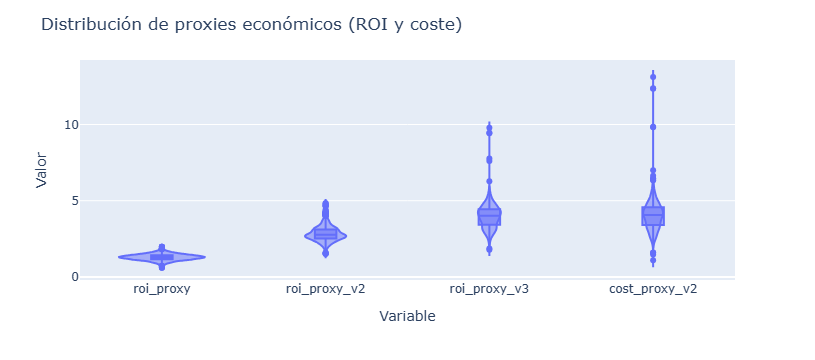

In [9]:
# Distribución de las variables de tipo ROI y proxies (Calculadas)

# Variables continuas
roi_continuous_vars = [
    "roi_proxy",
    "roi_proxy_v2",
    "roi_proxy_v3",
    "cost_proxy_v2"
]

# Pasamos a formato largo (long / tidy)
df_long = df_tablon[roi_continuous_vars].melt(
    var_name="variable",
    value_name="value"
)

fig = px.violin(
    df_long,
    x="variable",
    y="value",
    box=True,          # muestra boxplot interno
    # points="all",      # muestra puntos individuales
)

fig.update_layout(
    title="Distribución de proxies económicos (ROI y coste)",
    xaxis_title="Variable",
    yaxis_title="Valor",
    violingap=0.25,
)

fig.show()

We observe that the variable **`roi_proxy`** presents an approximately symmetric distribution, with the mean and median close to each other and located in the central range of values, which indicates that most patents concentrate ROI values around intermediate levels.
 
While both **`roi_proxy_v3`** and **`cost_proxy_v2`** show a right-skewed distribution, with several outliers located at high values (between 7 and 15), this means that there are many patents with modest returns and few with very high returns. **`roi_proxy_v2`**.

The transformation introduced in **`roi_proxy_v2`** significantly reduces the skewness of the distribution, limiting the influence of extreme values without eliminating the differentiation between high-value and low-value patents.

### Distribution of discrete ROI variables

Distribution of **`roi_proxy`** with respect to **`roi_class`**

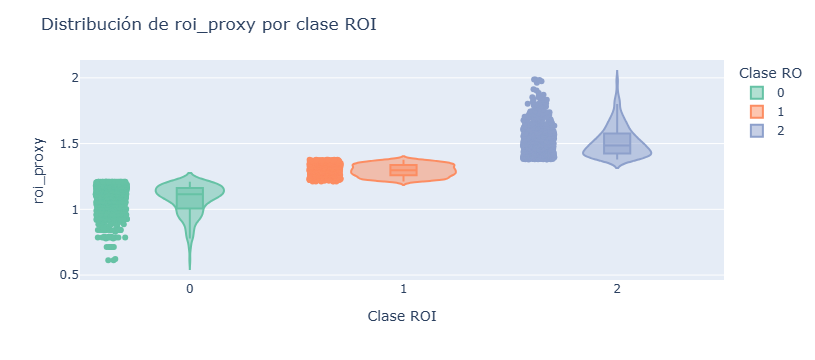

In [10]:
fig = px.violin(
    df_tablon,
    x="roi_class",
    y="roi_proxy",
    color="roi_class",  # ← clave para el colormap
    box=True,
    points="all",
    category_orders={
        "roi_class": sorted(df_tablon["roi_class"].dropna().unique())
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    title="Distribución de roi_proxy por clase ROI",
    xaxis_title="Clase ROI",
    yaxis_title="roi_proxy",
    legend_title="Clase ROI"
)

fig.show()

The figure shows the distribution of `roi_proxy` by ROI class. A clear and monotonic separation between the classes is observed, with a progressive shift of the distributions toward higher values as the class increases.

This indicates that the discretization of ROI is consistent with the continuous proxy and that the indicator adequately captures different levels of estimated return.

Distribution of **`roi_proxy_v3`** with respect to **`roi_class`**

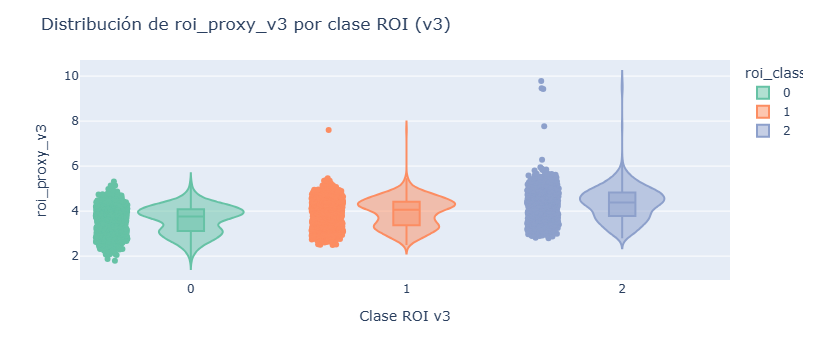

In [11]:
fig = px.violin(
    df_tablon,
    x="roi_class",
    y="roi_proxy_v3",
    color="roi_class",  # ← clave para el colormap
    box=True,
    points="all",
    category_orders={
        "roi_class": sorted(df_tablon["roi_class"].dropna().unique())
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_layout(
    title="Distribución de roi_proxy_v3 por clase ROI (v3)",
    xaxis_title="Clase ROI v3",
    yaxis_title="roi_proxy_v3"
)

fig.show()

Analogously to what was previously stated:

The figure shows the distribution of `roi_proxy_v3` by ROI_v3 class. A clear and monotonic separation between the classes is observed, with a progressive shift of the distributions toward higher values as the class increases.

This indicates that the discretization of ROI is consistent with the continuous proxy and that the indicator adequately captures different levels of estimated return.

## Patent actors variables (organizational complexity):

### Histograms and correlation between variables in the group (Applicants and inventors vs ROI)

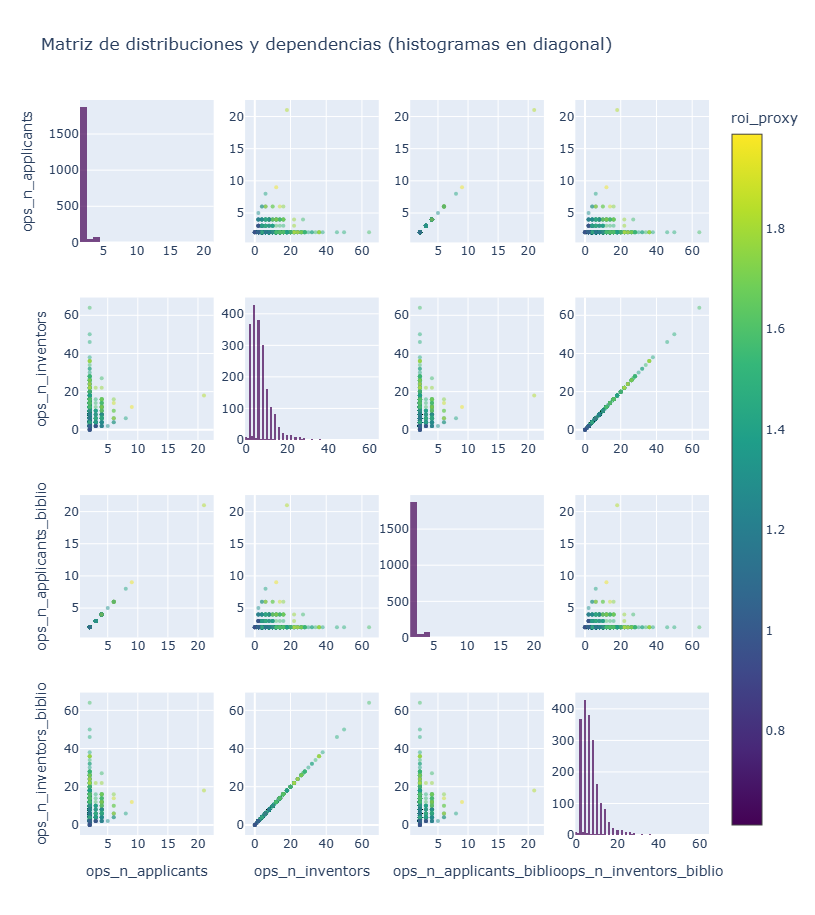

In [12]:
cols = [
    "ops_n_applicants",
    "ops_n_inventors",
    "ops_n_applicants_biblio",
    "ops_n_inventors_biblio",
]

df = df_tablon[cols + ["roi_proxy"]].dropna()
n = len(cols)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols):
    for j, x in enumerate(cols):

        # Diagonal → histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(
                        color="rgba(68,1,84,0.7)"
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal → scatter
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# 🔹 ETIQUETAS DE EJES
for i, col in enumerate(cols):
    # Eje Y (primera columna)
    fig.update_yaxes(
        title_text=col,
        row=i+1,
        col=1
    )

    # Eje X (última fila)
    fig.update_xaxes(
        title_text=col,
        row=n,
        col=i+1
    )

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias (histogramas en diagonal)",
)

fig.show()


## Distribution and dependency matrix between applicants and inventors

The previous figure shows a **distribution and dependency matrix** between the following variables:

- `ops_n_applicants`: number of applicants (OPS source)
- `ops_n_inventors`: number of inventors (OPS source)
- `ops_n_applicants_biblio`: number of applicants (bibliographic source)
- `ops_n_inventors_biblio`: number of inventors (bibliographic source)

The matrix is interpreted as follows:

---

### 🔹 Main diagonal: histograms (marginal distributions)

On the diagonal, **univariate histograms** are displayed, allowing the analysis of the distribution shape of each variable individually.

Main observations:

- All variables show a **strong right-skewed distribution**.
- Most patents have:
  - Very few applicants (1–3)
  - Very few inventors (1–5)
- There are **long tails** with high values, corresponding to:
  - Large companies
  - Collaborative projects
  - Complex patents or international consortia

This behavior justifies:
- The use of **logarithmic transformations**
- Careful treatment of **outliers**
- The use of robust statistics (median, IQR)

---

### 🔹 Off-diagonal: bivariate relationships

The off-diagonal cells display **scatter plots** between pairs of variables.

Each point represents a patent and is colored according to the value of `roi_proxy`, using a **sequential colormap**, which makes it possible to visually assess whether there is a relationship between structural complexity and estimated economic return.

#### Notable relationships:

- **`ops_n_inventors` vs `ops_n_inventors_biblio`**
  - Nearly **perfect linear relationship**
  - Indicates high consistency between both data sources
  - Suggests **informational redundancy** between these variables

- **`ops_n_applicants` vs `ops_n_applicants_biblio`**
  - Clear positive relationship, though with greater dispersion
  - Possible normalization differences between sources

- **Applicants vs inventors**
  - Weak–moderate positive relationship
  - Increasing the number of applicants does not necessarily imply a proportional increase in the number of inventors
  - Reflects different models of innovation organization

---

### 🔹 Economic interpretation (color by `roi_proxy`)

Coloring by `roi_proxy` suggests that:

- Patents with a higher number of inventors or applicants tend to show higher proxy return values, although:
  - The relationship is not strictly linear
  - There is substantial variability within each range

This indicates that organizational size or complexity **is not sufficient on its own** to explain economic return, reinforcing the need for multivariate models.

---

### 🔹 Key conclusions

- The variables exhibit **non-normal distributions** and long tails.
- There are **strong dependencies** between equivalent variables from different sources (OPS vs bibliography).
- **Collinearity** is detected, suggesting:
  - Selecting a single representative variable per pair
  - Or applying dimensionality reduction techniques
- The visual analysis supports the use of:
  - Log transformations
  - Robust models
  - Regularization to avoid redundancy

This matrix provides a fundamental exploratory view prior to the construction of predictive models for patent return.

## Technological classification variables (IPC / CPC):

### Histogram and correlation of discrete variables and comparison vs roi_proxy

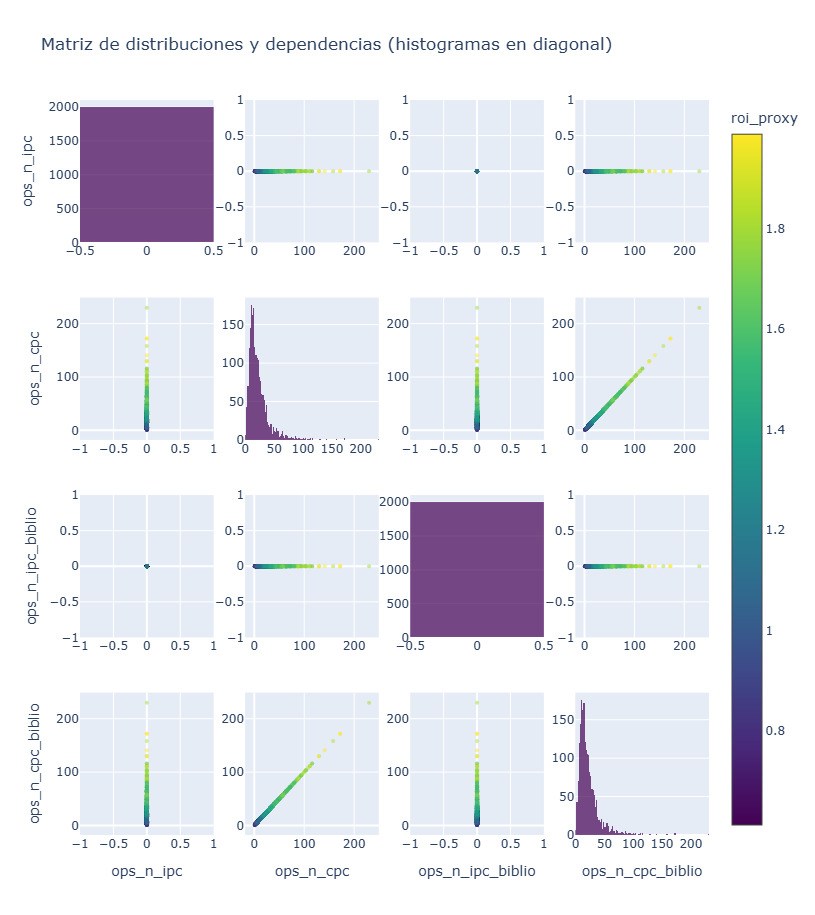

In [13]:
cols = [
    "ops_n_ipc",
    "ops_n_cpc",
    "ops_n_ipc_biblio",
    "ops_n_cpc_biblio",
]

df = df_tablon[cols + ["roi_proxy"]].dropna()
n = len(cols)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols):
    for j, x in enumerate(cols):

        # Diagonal → histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(
                        color="rgba(68,1,84,0.7)"
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal → scatter
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# 🔹 ETIQUETAS DE EJES
for i, col in enumerate(cols):
    # Eje Y (primera columna)
    fig.update_yaxes(
        title_text=col,
        row=i+1,
        col=1
    )

    # Eje X (última fila)
    fig.update_xaxes(
        title_text=col,
        row=n,
        col=i+1
    )

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias (histogramas en diagonal)",
)

fig.show()


### Histogram and correlation of discrete variables and comparison vs roi_proxy_v3

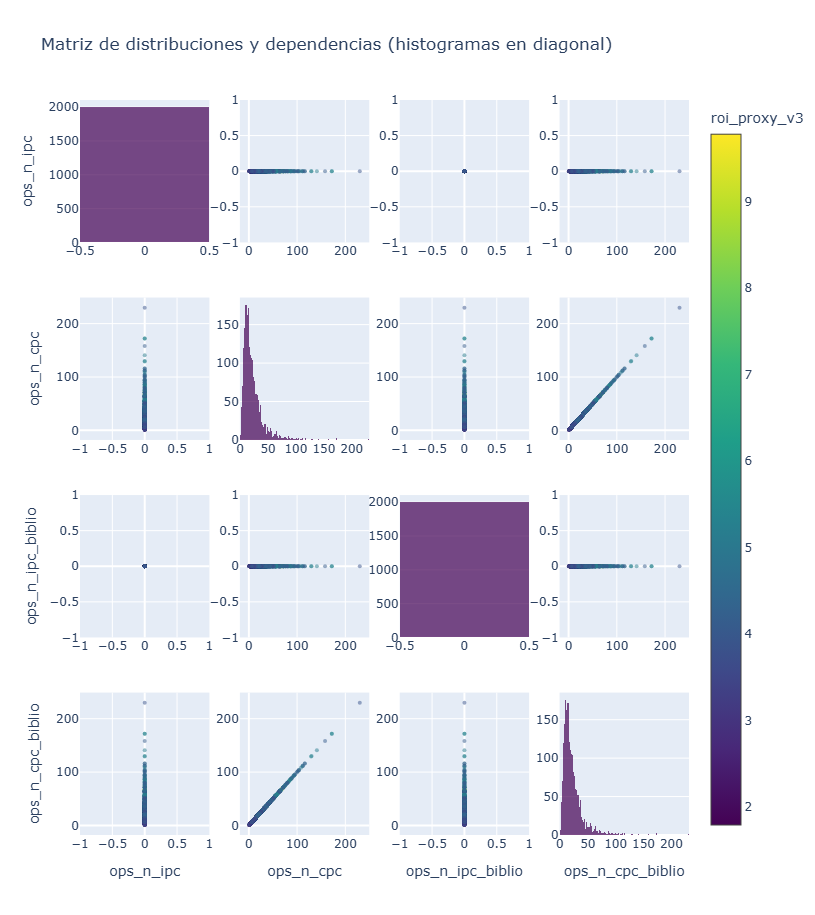

In [14]:
cols = [
    "ops_n_ipc",
    "ops_n_cpc",
    "ops_n_ipc_biblio",
    "ops_n_cpc_biblio",
]

df = df_tablon[cols + ["roi_proxy_v3"]].dropna()
n = len(cols)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols):
    for j, x in enumerate(cols):

        # Diagonal → histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(
                        color="rgba(68,1,84,0.7)"
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal → scatter
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# 🔹 ETIQUETAS DE EJES
for i, col in enumerate(cols):
    # Eje Y (primera columna)
    fig.update_yaxes(
        title_text=col,
        row=i+1,
        col=1
    )

    # Eje X (última fila)
    fig.update_xaxes(
        title_text=col,
        row=n,
        col=i+1
    )

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias (histogramas en diagonal)",
)

fig.show()


### Interpretation of the matrix using `roi_proxy` and `roi_proxy_v3`

When repeating the analysis using `roi_proxy` and `roi_proxy_v3` as the color variable, relevant differences are observed between the analyses, allowing for a deeper economic interpretation of the technological variables.

---

#### 🔹 1. IPC codes still do not provide explanatory variability

Consistent with the previous analysis, the variables:

- `ops_n_ipc`
- `ops_n_ipc_biblio`

show an extremely concentrated distribution, with very little effective variability.

Additionally:
- Coloring by `roi_proxy` does not reveal any significant gradient.
- These variables behave almost like constants.

Therefore, it is confirmed that **the number of IPC codes is not a good descriptor of either technical complexity or economic return**, regardless of the ROI proxy used.

---

#### 🔹 2. CPC codes capture technological effort and scope

Unlike the analysis with `roi_proxy_v3`, when using `roi_proxy` it is observed that:

- The variables `ops_n_cpc` and `ops_n_cpc_biblio` show a **slight color gradient**.
- Patents with a higher number of CPC codes tend to present higher values of `roi_proxy`.

This suggests that:
- The number of CPC codes is related to **technological effort**, classification breadth, and technical scope.
- `roi_proxy` partially captures these structural dimensions.

However, dispersion remains high, indicating that this relationship is **weak and non-deterministic**.

---

#### 🔹 3. Conceptual difference between both ROI proxies

The comparison between both matrices reveals that:

- `roi_proxy` is sensitive to variables related to **technological complexity and deployment**.
- `roi_proxy_v3`, by introducing cost penalties and temporal normalization, **eliminates this correlation**, retaining only relationships more directly linked to economic efficiency.

This behavior validates the progressive refinement of the proxy, showing how more sophisticated versions reduce spurious correlations.

---

#### 🔹 4. Redundancy between data sources

A nearly perfect relationship remains between:
- `ops_n_cpc` and `ops_n_cpc_biblio`
- `ops_n_ipc` and `ops_n_ipc_biblio`

This confirms that:
- Both sources contain equivalent information for these variables.
- Simultaneously including both introduces collinearity without informational gain.
- It is preferable to select a single source per type of variable.

---

#### 🔹 5. Implications for modeling

From this analysis it is concluded that:

- `ops_n_ipc` and `ops_n_ipc_biblio` can be discarded from the model.
- Only one of the CPC variables should be retained.
- The raw number of CPC codes may be useful as a descriptor of **technological effort**, but not as a direct proxy of economic return.
- It is more appropriate to use **derived proxies**, such as diversity or technological breadth measures, especially if the objective is to approximate economic efficiency.

---

#### 🔹 6. Added value of the comparative analysis

The comparison between `roi_proxy` and `roi_proxy_v3` makes it possible to:
- Distinguish between variables that explain **size, scope, or complexity**
- And those that explain **net return adjusted by costs**

This approach reinforces the methodological robustness of the study and justifies the use of refined proxies in advanced modeling stages.

The variable **`tech_breadth_proxy`** constitutes a derived continuous proxy that makes it possible to quantitatively capture the technological breadth of each patent, making it more suitable for statistical analysis and modeling.

## Calculation of **`tech_breadth_proxy`**:

In order to robustly capture the technological diversity or breadth of a patent, the proxy `tech_breadth_proxy` is defined.

### Definition

We define:

$$
tech\_breadth\_proxy = \log(1 + ops\_n\_cpc)
$$

This transformation:

- Captures technological breadth in an aggregated way.
- Reduces the impact of extreme values (long tails).
- Facilitates comparisons between patents.

<code>
    import numpy as np
    df_tablon["tech_breadth_proxy"] = np.log1p(df_tablon["ops_n_cpc"])
    df_tablon[["ops_n_cpc", "tech_breadth_proxy"]].head()
</code>

### Exclusion of `tech_breadth_proxy`

The variable `tech_breadth_proxy` is excluded from the independent analysis because it **acts as an intermediate proxy used in the construction of `proxy_roi`**.

Since `tech_breadth_proxy` synthesizes technological information that already directly contributes to the value of the return proxy, its additional use as a feature would produce **information leakage (target leakage)** and bias the evaluation of the model.

For this reason, `tech_breadth_proxy` is considered **endogenous to the objective** and is deliberately excluded from the set of analyzed variables.

## Technological classification variables (IPC / CPC)

The analysis of the technological dimension of the dataset has been constrained by several structural limitations in the available IPC/CPC classification variables. In particular, the fields corresponding to the main IPC code (`ops_ipc_main` and `ops_ipc_main_biblio`) do not contain reported values, while the number of IPC codes (`ops_n_ipc` and `ops_n_ipc_biblio`) exhibits very low variability, which limits their descriptive and predictive capacity.

For this reason, these variables are not suitable for direct inclusion in the analysis or in subsequent modeling.

Instead, the proxy **`tech_breadth_proxy`** has been defined and used, conceived as an aggregated measure of technological breadth based on the number of CPC codes assigned to each patent. This proxy captures, in a continuous and robust manner, the diversity of the technological space covered, avoiding the use of non-existent categorical labels and reducing the impact of long tails through a logarithmic transformation.

Empirical tests show that `tech_breadth_proxy` presents a statistically significant association with both `roi_proxy` and `roi_proxy_v3`, although with different magnitudes. This result indicates that technological breadth constitutes a relevant factor in explaining structural return proxies and maintains a moderate relationship with more economically adjusted return proxies.

Since no additional information is available regarding the hierarchical structure of IPC/CPC codes (for example, complete lists of codes per patent), it is not possible to construct more advanced metrics of technological diversity or concentration. Consequently, `tech_breadth_proxy` is considered an adequate and sufficient representation of the technological dimension in the context of this study, and it is incorporated as the sole variable of this category in the model, avoiding redundancies and the use of unavailable information.

## Patent family variables and international strategy

The patent family constitutes a key dimension for approximating the **international strategy and protection effort** associated with an invention. Unlike purely technological variables, family variables reflect strategic decisions by the applicant regarding geographical extension, legal scope, and the expected economic exploitation of the patent.

In general terms, a larger family with presence in multiple jurisdictions usually implies:
- higher economic costs of prosecution and maintenance,
- broader market expectations,
- and greater strategic relevance of the invention.

For this reason, family variables are considered indirect proxies of the perceived value of the patent from the applicant’s perspective.

---

### Available family variables

The dataset includes the following variables related to the patent family:

- `family_size_simple`: total number of documents composing the family.
- `family_country_count_simple`: number of distinct countries in which protection has been extended.
- `family_kinds_count_simple`: number of document types (kinds) within the family.

These variables capture different aspects of international strategy:

- `family_size_simple` reflects the **overall protection intensity**.
- `family_country_count_simple` explicitly measures the **geographical scope**.
- `family_kinds_count_simple` approximates the **procedural and legal complexity** of the family.

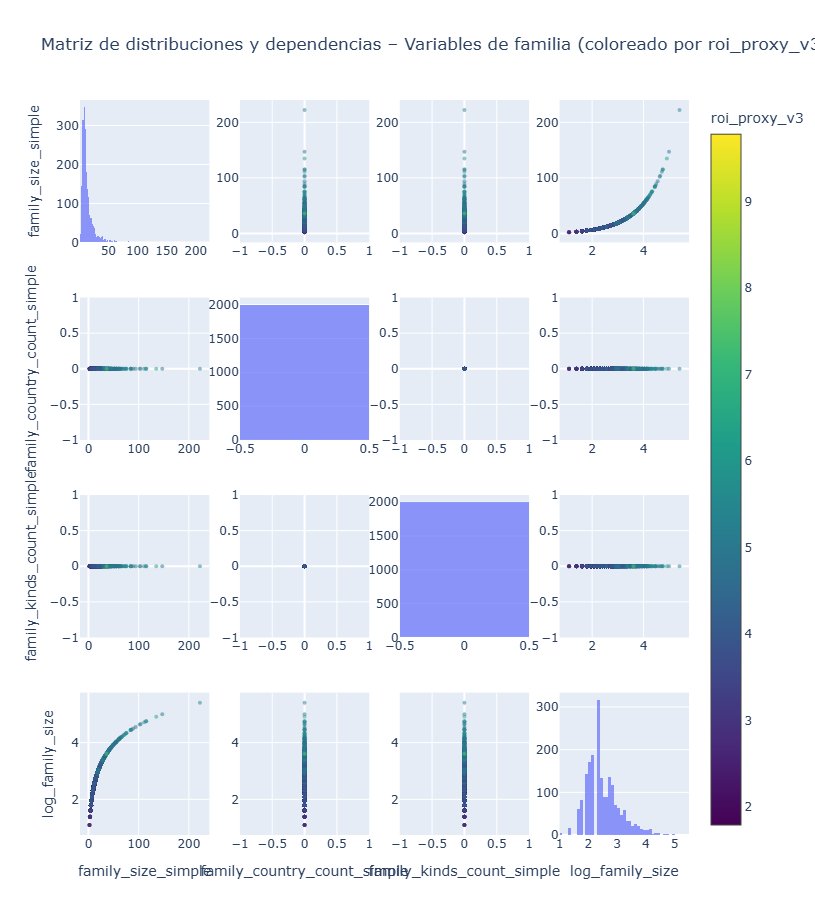

In [15]:
cols_family = [
    "family_size_simple",
    "family_country_count_simple",
    "family_kinds_count_simple",
    "log_family_size",
]

df = df_tablon[cols_family + ["roi_proxy_v3"]].dropna()
n = len(cols_family)

fig = make_subplots(
    rows=n,
    cols=n,
    shared_xaxes=False,
    shared_yaxes=False
)

for i, y in enumerate(cols_family):
    for j, x in enumerate(cols_family):

        # Diagonal: histogramas
        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(color="rgba(99,110,250,0.7)"),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

        # Fuera de diagonal: scatter con colormap ROI
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

# Etiquetas de ejes
for i, col in enumerate(cols_family):
    fig.update_yaxes(title_text=col, row=i+1, col=1)
    fig.update_xaxes(title_text=col, row=n, col=i+1)

fig.update_layout(
    height=900,
    width=900,
    title="Matriz de distribuciones y dependencias – Variables de familia (coloreado por roi_proxy_v3)"
)

fig.show()


The previous figure presents a matrix of distributions and dependencies between the patent family variables, with the adjusted economic return (`roi_proxy_v3`) represented through a colormap. The diagonal shows the marginal distributions, while the off-diagonal cells allow the evaluation of both collinearity among family metrics and their association with ROI. This joint visualization makes it possible to identify redundancies, detect non-linear relationships, and exploratorily assess the economic relevance of each variable.

We can observe that both **`family_country_count_simple`** and **`family_kinds_count_simple`** do not provide variability to the model, as they take fixed values.

On the other hand, since **`log_family_size`** and **`family_size_simple`** are related in the following way:

The variable `log_family_size` is defined as:

$$
\text{log\_family\_size}
=
\log\!\left( 1 + \text{family\_size\_simple} \right)
$$

We select the variable **`log_family_size`** as a potential predictor for the final model.

### Exclusion of `log_family_size` and `family_size_simple`

The variable `log_family_size` is not analyzed independently because it **explicitly forms part of the calculation formula of `proxy_roi`**.

Since `proxy_roi` includes patent family size (logarithmically transformed) as one of its components, analyzing `log_family_size` separately would introduce:

- Informational redundancy.
- Structural collinearity with the target variable.
- Bias in the interpretation of variable importance.

For this reason, `log_family_size` is considered **endogenous to `proxy_roi`** and is deliberately excluded from the set of independently analyzed variables.

On the other hand, the variable `family_size_simple` is not analyzed independently because it **directly forms part of the definition of the return proxy (`proxy_roi`)**.

Since patent family size is one of the structural components used to approximate the impact and potential value of an invention, its inclusion as an additional explanatory variable would introduce **informational redundancy** and **structural collinearity** with the target variable.

For this reason, `family_size_simple` is considered **endogenous to the ROI proxy** and is deliberately excluded from the independent analysis.

The analysis of the family variables shows that `family_country_count_simple` has a constant value equal to zero across the entire dataset, indicating a lack of variability and ruling out its use as an explanatory variable. Likewise, `family_kinds_count_simple` does not show a clear association with ROI once family size is taken into account.

## Legal events and legal status variables

### Motivation

Legal events associated with a patent reflect its **legal trajectory over time** and constitute a key source of information about its degree of exploitation, defense, and conflict. Unlike technological or family variables, which capture ex ante decisions of the applicant, legal events provide **ex post** information linked to the real life cycle of the patent.

From an economic perspective, greater legal activity may be interpreted as:
- greater maintenance and defense effort,
- greater strategic interest in the patent,
- or greater exposure to conflicts and disputes.

For this reason, legal variables are considered indirect proxies of both **economic value** and **legal risk**.

---

### Available legal variables

The dataset includes the following variables related to legal events and legal status:

- `legal_events_count`: total number of legal events recorded for the patent.
- `legal_codes_unique`: number of distinct legal codes associated with those events.
- `legal_first_date`: date of the first recorded legal event.
- `legal_last_date`: date of the last recorded legal event.
- `legal_has_grant_like`: binary indicator of grant or equivalent event.
- `legal_has_opposition_like`: binary indicator of opposition, revocation, or conflict.
- `legal_missing_dates`: number of legal events without a valid date.

These variables allow the characterization of both the **intensity** and the **nature** of the legal activity associated with each patent.

---

### Conceptual interpretation of the variables

- **Legal intensity**
  - `legal_events_count` and `legal_codes_unique` measure the volume and diversity of legal activity.
  - High values indicate patents with active life cycles and potentially costly maintenance.

- **Temporal trajectory**
  - `legal_first_date` and `legal_last_date` make it possible to reconstruct the duration and validity of the legal history.
  - The difference between these dates approximates the observed **legal lifespan** of the patent.

- **Key legal status**
  - `legal_has_grant_like` identifies patents that have reached a relevant legal milestone (grant).
  - `legal_has_opposition_like` captures the existence of conflicts, oppositions, or disputes.

- **Data quality**
  - `legal_missing_dates` acts as an indicator of incompleteness or noise in the legal history, relevant for assessing the reliability of temporal variables.

### Graphical analysis of legal variables

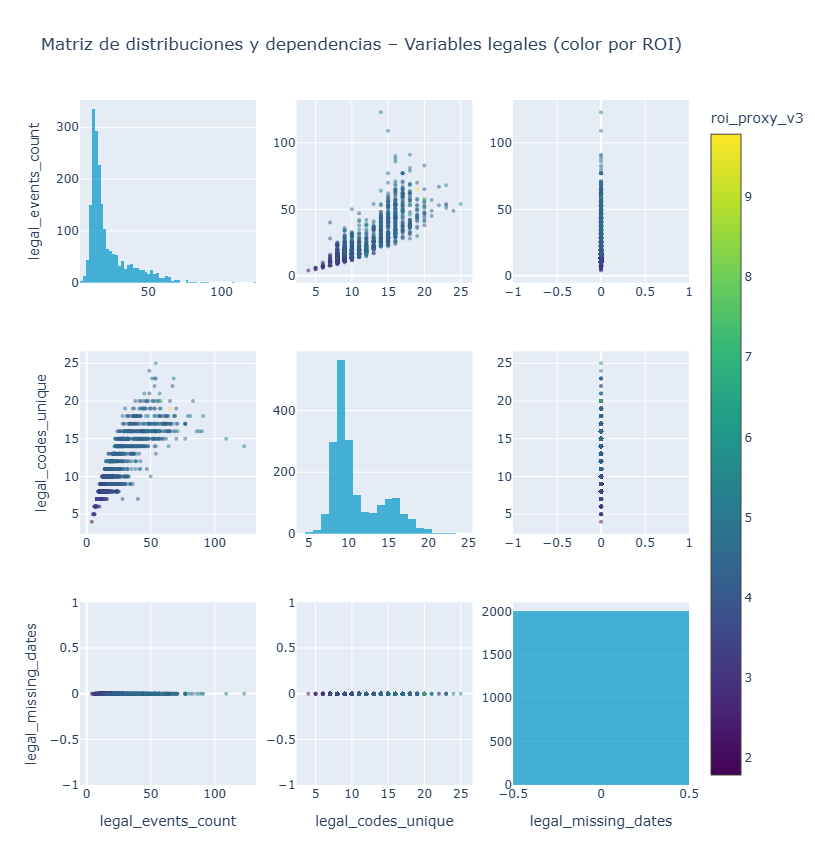

In [16]:
legal_vars = [
    "legal_events_count",
    "legal_codes_unique",
    "legal_missing_dates",
]

df = df_tablon[legal_vars + ["roi_proxy_v3"]].dropna()
n = len(legal_vars)

fig = make_subplots(rows=n, cols=n)

for i, y in enumerate(legal_vars):
    for j, x in enumerate(legal_vars):

        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(color="rgba(0,150,200,0.7)"),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

for i, col in enumerate(legal_vars):
    fig.update_yaxes(title_text=col, row=i+1, col=1)
    fig.update_xaxes(title_text=col, row=n, col=i+1)

fig.update_layout(
    height=850,
    width=850,
    title="Matriz de distribuciones y dependencias – Variables legales (color por ROI)"
)

fig.show()


### Graphical interpretation:

The two variables: **`legal_events_count`**, **`legal_codes_unique`** show variability with different distributions. In both cases, while **`legal_events_count`** appears to follow a right-skewed distribution, **`legal_codes_unique`** resembles a bimodal distribution.

By contrast, **`legal_missing_dates`** does not provide informative value to the model.

We also observe that, a priori, both **`legal_events_count`** and **`legal_codes_unique`** have explanatory capacity regarding the variability of `proxy_roi_v3`. In the subsequent hypothesis tests, we will verify this finding.

To graphically understand the binary indicators, we use the following plots:

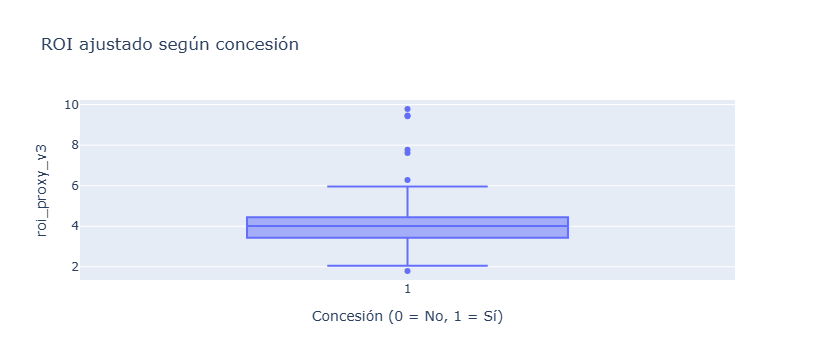

In [17]:
fig = px.box(
    df_tablon,
    x="legal_has_grant_like",
    y="roi_proxy_v3",
    title="ROI ajustado según concesión",
    labels={"legal_has_grant_like": "Concesión (0 = No, 1 = Sí)"}
)
fig.show()

La variable: **´legal_has_grant_like´** no ofrece ninguna explicación sobre proxy_roi_v3, por lo que la podemos descartar del modelo final.

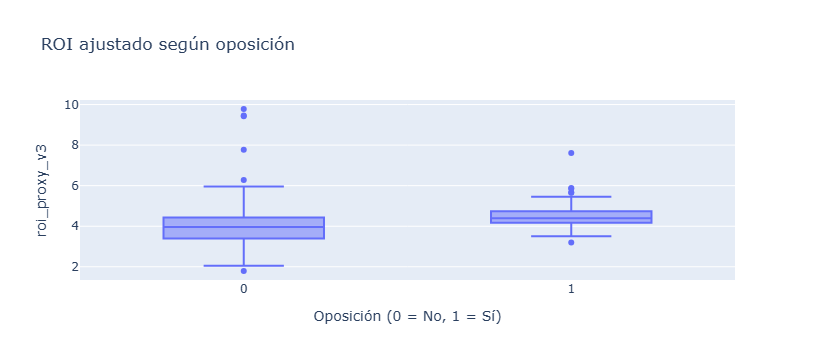

In [18]:
fig = px.box(
    df_tablon,
    x="legal_has_opposition_like",
    y="roi_proxy_v3",
    title="ROI ajustado según oposición",
    labels={"legal_has_opposition_like": "Oposición (0 = No, 1 = Sí)"}
)
fig.show()


In this case, **`legal_has_opposition_like`** shows variance and values distributed across each value of `roi_proxy_v3`, which suggests that this variable may be useful for the model. We will confirm this through an appropriate hypothesis test.

## Hypothesis test: relationship between **`legal_codes_unique`** and ROI

### Hypotheses
For each ROI proxy and for both variables:
- H₀: `legal_codes_unique` is independent of ROI
- H₁: there is a monotonic association between the two

We use Spearman (robust, does not assume normality):

### Exclusion of `legal_events_count`

The variable `legal_events_count` is excluded from the independent analysis because it **is explicitly used as a component of the return proxy (`proxy_roi`)**, as it captures the intensity and legal evolution of the file.

Including this variable as an additional feature would imply analyzing the same underlying factor twice, generating **deterministic dependence** with the target variable and compromising the interpretation of the results.

Therefore, `legal_events_count` is considered **a constitutive part of the ROI proxy** and is not incorporated as an independent explanatory variable.

### Exclusión de `legal_codes_unique`

La variable `legal_codes_unique` no se analiza de forma independiente porque **interviene directamente en el cálculo del proxy de retorno (`proxy_roi`)**, representando la diversidad de eventos legales asociados a la patente.

Su inclusión como variable explicativa introduciría **colinealidad estructural** y **sobreponderación artificial** del componente legal dentro del modelo, al reforzar un factor ya incorporado en la variable objetivo.

En consecuencia, `legal_codes_unique` se excluye del análisis como variable independiente.

## Hypothesis test: relationship between **`legal_has_opposition_like`** and ROI

### Hypotheses
For **`legal_has_opposition_like`** with respect to `proxy_roi_v3`:
- H₀: The ROI distribution is the same for patents with and without opposition.
- H₁: The distributions are different.

We use the Mann–Whitney U method:
(*) We do not assume normality → non-parametric test.

In [19]:
# separar grupos
group_0 = df_tablon.loc[
    df_tablon["legal_has_opposition_like"] == 0,
    "roi_proxy_v3"
].dropna()

group_1 = df_tablon.loc[
    df_tablon["legal_has_opposition_like"] == 1,
    "roi_proxy_v3"
].dropna()

# test Mann–Whitney
u_stat, p_value = mannwhitneyu(
    group_0,
    group_1,
    alternative="two-sided"
)


print(
    f"""
Test Mann–Whitney -U
u_stat: {u_stat},
pvalue: {p_value}, 
    """)

ks_stat, p_value_ks = ks_2samp(group_0, group_1)

print(f"""
Test Kolmogorov–Smirnov (KS)
ks_stat: {ks_stat}
p_value_ks {p_value_ks}
""")



Test Mann–Whitney -U
u_stat: 49599.0,
pvalue: 2.6694290679703875e-13, 
    

Test Kolmogorov–Smirnov (KS)
ks_stat: 0.4026972692243257
p_value_ks 1.3081355975904625e-13



The relevance of the binary legal variables has been evaluated through non-parametric tests, comparing the ROI distribution between patents with and without specific legal events. In particular, the Mann–Whitney U test has been applied to test the null hypothesis of equality of distributions, complemented by the Kolmogorov–Smirnov test to assess differences in the overall shape of the distribution. This approach makes it possible to evaluate the economic significance of events such as opposition or grant without assuming normality or linearity.

From the previous hypothesis test using the **Mann–Whitney U test**, we observe that since p_value < 0.05, there is sufficient evidence to reject the null hypothesis.

We therefore conclude by accepting the alternative hypothesis, that is: the distributions for the different values of **`legal_has_opposition_like`** are different, which means that the variable is statistically relevant for explaining ROI.

On the other hand, and thanks to the corroboration using the **Kolmogorov–Smirnov (KS) test**, we can infer the following: since p_value_ks remains below 0.05, we confirm that the variable `legal_has_opposition_like` is considered statistically relevant and is incorporated as a candidate explanatory variable in the subsequent analysis.

### Proxy derived from legal dates: **`legal_mid_date`**, **`mid_to_pub_days`** and **`alignment_score`**

## Temporal proxies based exclusively on legal dates

These proxies are constructed **exclusively** from:

- `legal_first_date`
- `legal_last_date`

They do not use any external temporal reference (current date,
publication date, etc.), which guarantees that they do not introduce
*temporal leakage* in predictive models.

Each proxy is calculated row by row using pure functions applied
with `DataFrame.apply(axis=1)`.

---

### Proxy 1 — Legal delta (activity duration)

Measures the total duration of the legal interval:

$$
\Delta t = | legal\_last\_date - legal\_first\_date |
$$

- Captures the legal “lifetime” of the asset.
- High values indicate sustained activity over time.

---

### Proxy 2 — Smoothed delta (log-life)

To avoid long tails, a logarithmic transformation is applied:

$$
\text{delta\_log} = \log(1 + \Delta t)
$$

- More stable for linear and regularized models.
- Comparable scale across very different families.

---

### Proxy 3 — Compact life (temporal intensity)

Favors concentrated legal activity and penalizes excessively long intervals:

$$
\text{compact\_life} = \frac{\log(1 + \Delta t)}{1 + \Delta t}
$$

- Maximum for short–medium durations.
- Useful as a signal of active management.

In [20]:
# --- Proxy 1: delta simple ---
delta_days = lambda r: (
    abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days)
    if pd.notna(r.iloc[0]) and pd.notna(r.iloc[1])
    else np.nan
)

df = df_tablon.copy()
df["legal_delta_days"] = df[
    ["legal_first_date", "legal_last_date"]
].apply(delta_days, axis=1)


# --- Proxy 2: delta log ---
delta_log = lambda r: (
    np.log1p(abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days))
    if pd.notna(r.iloc[0]) and pd.notna(r.iloc[1])
    else np.nan
)

df["legal_delta_log"] = df[
    ["legal_first_date", "legal_last_date"]
].apply(delta_log, axis=1)


# --- Proxy 3: vida compacta ---
compact_life = lambda r: (
    np.log1p(abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days))
    / (1 + abs((pd.to_datetime(r.iloc[1]) - pd.to_datetime(r.iloc[0])).days))
    if pd.notna(r.iloc[0]) and pd.notna(r.iloc[1])
    else np.nan
)

df["legal_compact_life"] = df[
    ["legal_first_date", "legal_last_date"]
].apply(compact_life, axis=1)

In [21]:
def spearman_test(df, x, y="roi_proxy"):
    data = df[[x, y]].dropna()
    rho, p = spearmanr(data[x], data[y])
    return {
        "proxy": x,
        "spearman_rho": rho,
        "p_value": p,
        "n": len(data)
    }

proxies = [
    "legal_delta_days",
    "legal_delta_log",
    "legal_compact_life"
]

results_spearman = pd.DataFrame(
    [spearman_test(df, p) for p in proxies]
)

results_spearman


,proxy,spearman_rho,p_value,n
0,legal_delta_days,-0.053528,0.01669,1999
1,legal_delta_log,-0.053528,0.01669,1999
2,legal_compact_life,0.053528,0.01669,1999


### Conclusion

Each legal temporal proxy shows a correlation with the ROI proxy
when analyzed in a **bivariate and independent** manner.  
The magnitude of this correlation is **weak**, but **statistically significant**,
indicating the presence of a real signal, albeit with low individual impact.

Although the legal temporal proxies display a statistically significant
bivariate correlation with the ROI proxy, the effect size is small.
For this reason, they are considered auxiliary signals and are not prioritized as
main explanatory variables in the model.

## Temporal metrics derived from legal history

Temporal metrics derived from legal history aim to capture the **dynamics, persistence, and temporal validity** of a patent throughout its legal life cycle. Unlike aggregated counts of legal events, these variables explicitly incorporate the time dimension, allowing analysis not only of how many events occur, but also **when** they occur and **for how long** legal activity remains active.

From an economic perspective, the temporal persistence of a patent often reflects:
- sustained maintenance and defense efforts,
- continued expectations of commercial exploitation,
- and greater perceived strategic value over time.

The variables included in this group characterize different aspects of this dynamic:

- `years_since_first_legal` and `years_since_last_legal` measure the temporal distance from the main legal milestones, providing information about the maturity and recent activity of the patent.
- `alive_span_days` and `alive_years` approximate the total duration of the observed legal history, capturing the legal longevity of the patent.
- `events_per_year` summarizes the average intensity of legal activity, normalizing the number of events by the duration of the history.
- `is_active_recent` identifies patents with recent legal activity, acting as an indicator of current validity and relevance.

Taken together, these metrics make it possible to distinguish between patents with isolated legal activity and those with persistent legal presence, providing complementary information to family, technological, and aggregated legal event variables. For this reason, they are considered relevant proxies for analyzing the relationship between temporal legal trajectory and the economic return associated with the patent.

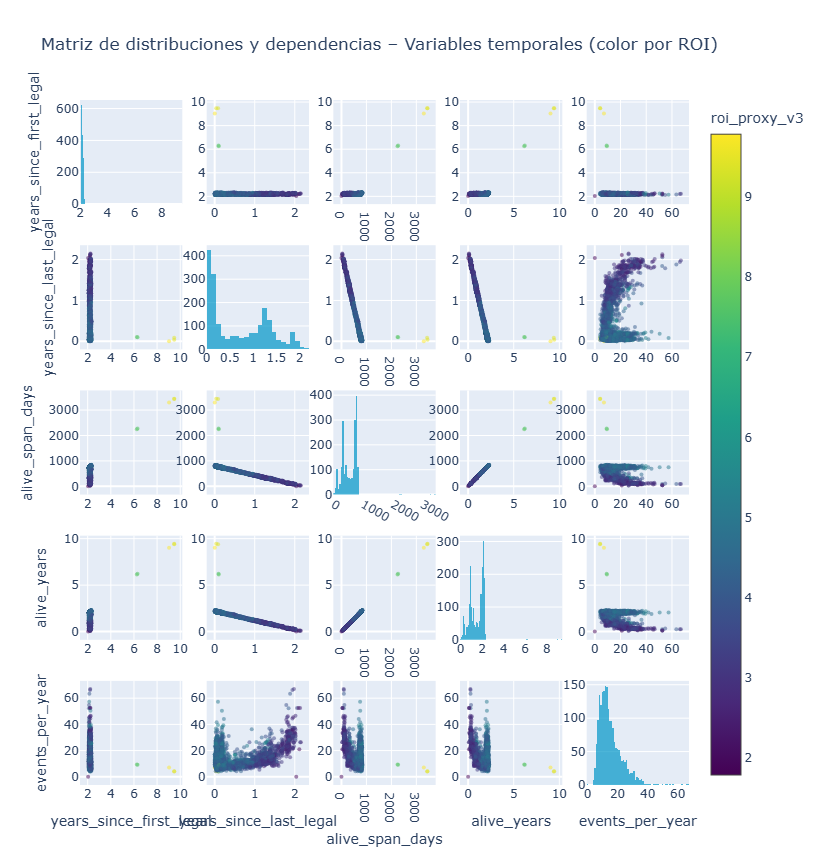

In [22]:
temporal_vars = [
    "years_since_first_legal",
    "years_since_last_legal",
    "alive_span_days",
    "alive_years",
    "events_per_year",
    ]

df = df_tablon[temporal_vars + ["roi_proxy_v3"]].dropna()
n = len(temporal_vars)

fig = make_subplots(rows=n, cols=n)

for i, y in enumerate(temporal_vars):
    for j, x in enumerate(temporal_vars):

        if i == j:
            fig.add_trace(
                go.Histogram(
                    x=df[x],
                    marker=dict(color="rgba(0,150,200,0.7)"),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )
        else:
            fig.add_trace(
                go.Scatter(
                    x=df[x],
                    y=df[y],
                    mode="markers",
                    marker=dict(
                        color=df["roi_proxy_v3"],
                        colorscale="Viridis",
                        size=4,
                        opacity=0.5,
                        showscale=(i == 0 and j == n - 1),
                        colorbar=dict(title="roi_proxy_v3")
                    ),
                    showlegend=False
                ),
                row=i+1, col=j+1
            )

for i, col in enumerate(temporal_vars):
    fig.update_yaxes(title_text=col, row=i+1, col=1)
    fig.update_xaxes(title_text=col, row=n, col=i+1)

fig.update_layout(
    height=850,
    width=850,
    title="Matriz de distribuciones y dependencias – Variables temporales (color por ROI)"
)

fig.show()


Observamos que existen variables con dependencia lineal dos a dos, como:
 - **`alive_spam_days`** y **`alive_years`**
 - **`year_since_last_legal`** y **`alive_years`**

Lo cual tiene sentido porque una es función de la otra, de estas variables habrá que quedarse con una de la pareja unicamente para el modelo, por otra parte se ve que existe varibilidad para los distintos valores de proxy_roi_v3 lo que noas una idea de que estas variables ayudan a explicar el proxy_roi_v3 por lo que incluirán en el modelo. 

## Contraste de hipoteis relacción **`is_active_recent`** frente a ROI

### Hipótesis
Para **`is_active_recent`** con respecto a proxy_roi_v3:
- H₀: La distribución de ROI es la misma para patentes con y sin oposición.
- H₁: Las distribuciones son distintas.

Usamos el método de Mann–Whitney U:
(*) No asumimos normalidad → test no paramétrico.

In [23]:
# separar grupos
group_0 = df_tablon.loc[
    df_tablon["is_active_recent"] == 0,
    "roi_proxy_v3"
].dropna()

group_1 = df_tablon.loc[
    df_tablon["is_active_recent"] == 1,
    "roi_proxy_v3"
].dropna()

# test Mann–Whitney
u_stat, p_value = mannwhitneyu(
    group_0,
    group_1,
    alternative="two-sided"
)


print(
    f"""
Test Mann–Whitney -U
u_stat: {u_stat},
pvalue: {p_value}, 
    """)

ks_stat, p_value_ks = ks_2samp(group_0, group_1)

print(f"""
Test Kolmogorov–Smirnov (KS)
ks_stat: {ks_stat}
p_value_ks {p_value_ks}
""")



Test Mann–Whitney -U
u_stat: 67750.0,
pvalue: 1.8489338974018826e-228, 
    

Test Kolmogorov–Smirnov (KS)
ks_stat: 0.7312466179653679
p_value_ks 1.4921074526761139e-246



## Text and length: simple semantic signals

This group of variables collects basic information derived from the **textual content** of the patent, specifically from its title and abstract. Unlike technological, legal, or strategic variables, these metrics do not describe administrative decisions or legal events, but rather capture **formal properties of the technical discourse** used to describe the invention.

The objective of this block is not to analyze the deep semantic meaning of the text, but to incorporate **simple, quantifiable, and comparable signals** that reflect how the invention is presented from a descriptive perspective.

---

### Included variables

- `ops_title`: patent title.
- `ops_abstract`: patent abstract.
- `title_len`: title length, measured as number of characters or tokens.
- `abstract_len`: abstract length, measured as number of characters or tokens.

---

### Conceptual interpretation

The title and abstract constitute the main elements of **technical communication** in a patent. Although their semantic content is not directly analyzed at this stage, their length may be interpreted as an indirect signal of different aspects of the invention:

- **Perceived level of technical complexity**: more complex inventions or those with multiple aspects may require more extensive descriptions.
- **Degree of specificity**: longer titles and abstracts may reflect greater effort to delimit the technical scope of the invention.
- **Drafting strategy**: text length may respond to sectoral practices, applicant habits, or technological domain conventions.

In this sense, `title_len` and `abstract_len` are interpreted as **formal proxies**, not semantic ones, of the descriptive effort associated with the patent.

---

### Assumptions and limitations

It is important to note that these variables:

- Do not capture the technical content or quality of the invention.
- Do not directly reflect economic value, impact, or novelty.
- May be influenced by external factors, such as drafting styles, formal requirements, or institutional practices.

Therefore, their interpretation must be carried out with caution and always as **complementary signals**, not as direct determinants of economic return.

---

### Expected role in the analysis

Text length metrics may provide additional information to the model by capturing systematic differences in how patents are presented. In particular, they may be useful to:

- control for descriptive complexity effects,
- identify general drafting patterns,
- complement technological and legal variables without introducing strong dependencies.

However, their inclusion in the final model will depend on their empirical capacity to provide incremental information once other, more structural dimensions of patent value have been considered.

### Hypothesis test for the variable `is_active_recent`

The relevance of the binary variable `is_active_recent` has been evaluated by comparing the ROI distribution between patents with and without recent legal activity. To this end, the non-parametric Mann–Whitney U and Kolmogorov–Smirnov tests have been applied, as they are suitable for skewed distributions and do not assume normality.

The Mann–Whitney test yields a U statistic of 67,750 and a p-value below 10⁻²²⁸, allowing a clear rejection of the null hypothesis of equality in distribution location. Complementarily, the Kolmogorov–Smirnov test shows a KS statistic of approximately 0.73 and a p-value below 10⁻²⁴⁶, indicating a substantial difference in the overall shape of the ROI distributions between both groups.

These results provide very strong statistical evidence that recent legal activity is strongly associated with economic return, justifying the inclusion of `is_active_recent` as a relevant explanatory variable in the model.

## Bibliographic variables and administrative timeline

This block of variables describes the **temporal and administrative dimension** of the patent, making it possible to reconstruct its evolution from the initial priority to official publication. Unlike technological or legal variables, these metrics capture aspects **exogenous to the technical content**, yet fundamental for understanding asset maturity, prosecution timelines, and potential exploitation windows.

The included variables are:

- `biblio_priority_count`: number of priorities claimed by the patent, an indicator of strategic complexity and reuse of prior results.
- `biblio_priority_date_min`: earliest declared priority date, marking the effective start of protection.
- `biblio_priority_year`: year corresponding to the earliest priority, used for temporal cohort analysis.
- `biblio_application_date`: official patent application date.
- `biblio_application_year`: application year, enabling analysis of historical trends and activity cycles.
- `biblio_publication_date`: official publication date of the document.
- `biblio_publication_year`: publication year, indicating when technical information becomes public.
- `biblio_kind`: document *kind* code (for example, A1, B1), identifying the phase and legal nature of the publication.

Taken together, these variables allow characterization of the **administrative timeline** of each patent and analysis of possible **delays, legal maturity, and temporal exploitation windows**. This information complements technological and legal metrics, providing structural context for the analysis of economic return without introducing direct dependencies on the technical content of the invention.

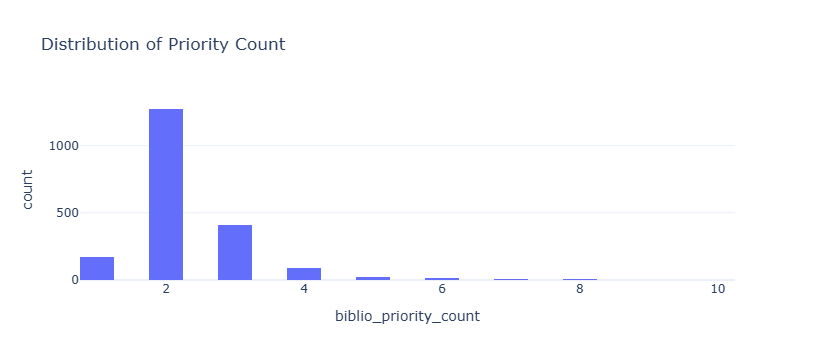

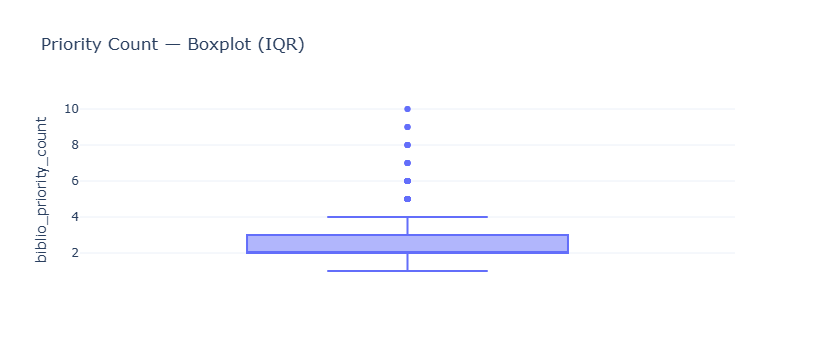

In [24]:
df = df_tablon.copy()

fig = px.histogram(
    df,
    x="biblio_priority_count",
    nbins=40,
    title="Distribution of Priority Count",
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.box(
    df,
    y="biblio_priority_count",
    points="outliers",
    title="Priority Count — Boxplot (IQR)"
)
fig.update_layout(template="plotly_white")
fig.show()


## Analysis of `biblio_priority_count`
**Objective:** identify concentration in few priorities and the presence of a tail of complex families (advanced international strategy).

---

## 1) Concentration in 0–1 priorities (simple families)

### Empirical evidence
- The **histogram** shows a dominant mass at **low values (1–2 priorities)**.
- The **boxplot (IQR)** confirms:
  - Median ≈ **2**
  - Narrow IQR (approx. **2–3**)
  - A large proportion of observations concentrated near the minimum.

### Interpretation
- Most patents correspond to **simple families**:
  - a single priority or
  - one main priority with very few extensions.
- This is typical of:
  - individual applicants or SMEs,
  - national or regional strategies,
  - inventions with limited technological or commercial scope.

**Structural reading**
> The system is dominated by assets with low international complexity, which is consistent with real-world patent office distributions.

---

## 2) Tail of complex families (advanced international strategy)

### Empirical evidence
- The boxplot shows clear **outliers** starting at:
  - `biblio_priority_count ≥ 5`
  - reaching values close to **8–10**.
- In the histogram:
  - frequency drops rapidly,
  - but **does not disappear**, forming a long right tail.

### Interpretation
These observations represent **complex patent families**, typically associated with:
- well-executed PCT strategies,
- multiple priorities (continuations, divisionals, staged filings),
- large companies or actors with mature IP departments,
- inventions with **high economic or strategic potential**.

**Structural reading**
> There is a small but significant minority of patents with an advanced international strategy, clearly differentiated from the bulk of the dataset.

---

## 3) Skewed distribution and statistical consequences

### Distribution characteristics
- **Strong positive skewness** (right-skewed).
- Mean > median (not shown, but implied).
- Outliers are not noise: they are **informative**.

### Implications
- It is not a Gaussian variable.
- High values of `biblio_priority_count` are **semantically relevant**, not errors.
- Methods sensitive to outliers (e.g., linear regression without transformation) may be dominated by the tail.

---

## 4) Recommendations for use in analysis / model

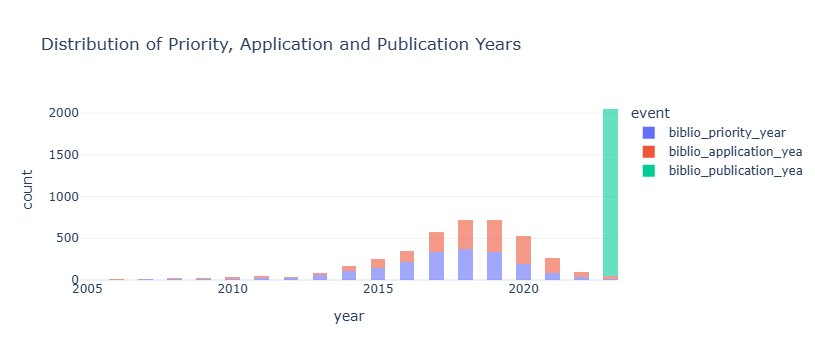

In [25]:
years_df = df[[
    "biblio_priority_year",
    "biblio_application_year",
    "biblio_publication_year"
]].melt(var_name="event", value_name="year")

fig = px.histogram(
    years_df,
    x="year",
    color="event",
    nbins=50,
    opacity=0.6,
    title="Distribution of Priority, Application and Publication Years"
)

fig.update_layout(template="plotly_white")
fig.show()


### 1) Temporal shifts (structural lags)

The chart shows the expected chronological order of the patent life cycle:

- **Priority → Application → Publication**

Interpretation:
- `biblio_priority_year` systematically appears **before** `biblio_application_year`.
- `biblio_application_year` is typically **1–2 years after** the priority date (typical priority→application lag).
- `biblio_publication_year` appears **later** and tends to be **more concentrated** in recent years (typical priority→publication lag of ~2–3 years, varying by jurisdiction and procedure).

**Conclusion:** the dataset reflects a reasonable legal chronology and these lags are *structural*, not noise.  
**Implication:** for analysis and modeling, it is advisable to use `biblio_priority_year` as the “neutral” temporal reference (cycle origin).

---

### 2) Cohort concentration (cohort effect)

A strong concentration of records can be observed within a range of years (peaks around **2016–2019**, approx.):

- Many patents share a common priority/application “window” in those years.
- From 2020 onwards, a decline is observed that **most likely does NOT** represent a real drop, but rather an effect of the calendar and the extraction process itself.

**Key concept:** *Right-censoring*  
More recent patents have not yet had time to:
- accumulate events,
- legally mature,
- reflect derived indicators (e.g., event counts, family metrics, etc.).

**Implication:** directly comparing very recent cohorts with older cohorts without adjusting for “age” may bias correlations, distributions, and models.

---

### 3) Historical evolution (system dynamics)

An underlying trend can be observed:
- progressive growth from earlier years,
- acceleration from around ~2013–2014,
- peak in 2017–2019,
- apparent “decline” in recent years, largely attributable to temporal censoring / incompleteness.

**Conclusion:** recent evolution must be interpreted with caution, as the most recent years are typically incomplete by definition.

In [26]:
df["publication_delay_years"] = (
    df["biblio_publication_year"] - df["biblio_priority_year"]
)


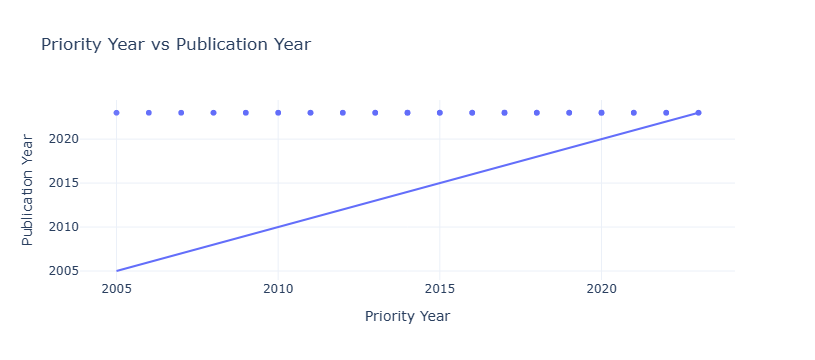

In [27]:
fig = px.scatter(
    df,
    x="biblio_priority_year",
    y="biblio_publication_year",
    opacity=0.5,
    title="Priority Year vs Publication Year",
    labels={
        "biblio_priority_year": "Priority Year",
        "biblio_publication_year": "Publication Year"
    }
)

fig.add_traces(
    px.line(
        x=[df["biblio_priority_year"].min(), df["biblio_priority_year"].max()],
        y=[df["biblio_priority_year"].min(), df["biblio_priority_year"].max()]
    ).data
)

fig.update_layout(template="plotly_white")
fig.show()


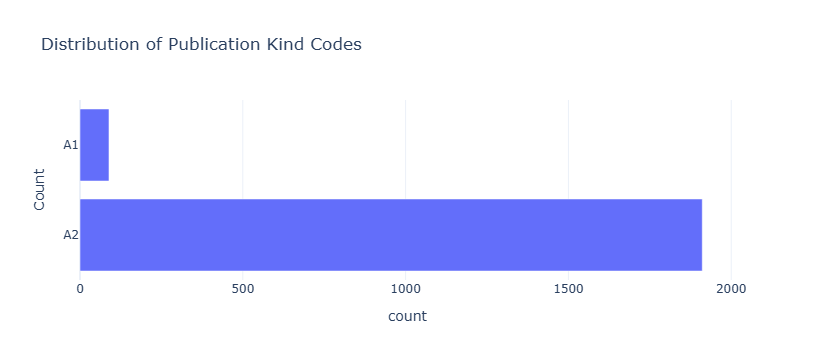

In [28]:
fig = px.bar(
    df["biblio_kind"].value_counts().reset_index(),
    x="count",
    y="biblio_kind",
    title="Distribution of Publication Kind Codes",
    labels={"index": "Kind Code", "biblio_kind": "Count"}
)
fig.update_layout(template="plotly_white")
fig.show()


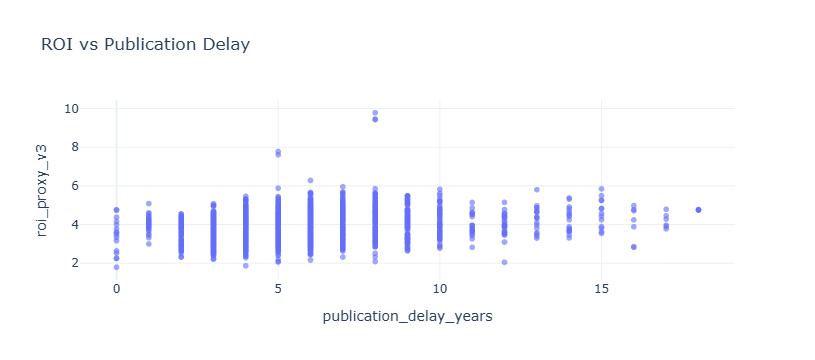

In [29]:
fig = px.scatter(
    df,
    x="publication_delay_years",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Publication Delay"
)
fig.update_layout(template="plotly_white")
fig.show()


Bibliographic variables make it possible to reconstruct the administrative timeline of the patent, from the initial priority to its publication. The joint analysis of years, delays, and publication codes provides information on the legal maturity of the asset, prosecution timelines, and potential exploitation windows. These temporal dimensions complement technological and legal variables, providing structural context for the analysis of economic return.

## Variable `biblio_kind` (A1/A2) and its role in an ROI (proxy) model

### What it is (and what it is NOT)
- `biblio_kind` usually takes **A1** or **A2**:
  - **A1**: publication with search report (search included).
  - **A2**: publication without search report (issued later).
- Therefore, it encodes **editorial/procedural status**, not “quality” or “value” directly.

- “A2 ⇒ more ‘green’ / less documentarily mature patent”, which affects proxies that require time.

### Why it does NOT “conclude” ROI
- It is a **low-entropy variable** (only 2 values).
- It is **strongly linked to time/maturity** (right-censoring).
- It is not causal of value: it is a **status marker**.

### Correct use in the model
`biblio_kind` is used as:
- A **control variable** (document maturity),
- or for **filtering/stratifying**:
  - main analysis only with A1 (mature cohorts),
  - separate analysis for A2.

> In summary: `biblio_kind` does not “explain” ROI; it helps **avoid attributing to ROI** what is actually **lack of temporal maturity**.

---

## Temporal variables and their interpretation (what we already observed)
**Variables:**
- `biblio_priority_year`, `biblio_application_year`, `biblio_publication_year`

**Findings from the chart:**
- There is a structural lag: priority → application → publication.
- There is **cohort concentration** (peaks 2016–2019).
- Recent cohorts suffer from **right-censoring** (temporal incompleteness).

**Implication for ROI/proxies:**
- Controlling for “age” is mandatory (e.g., `age_since_priority`).
- Performing cohort-based analysis/validation avoids bias.

---

## `biblio_priority_count`: simple vs complex families
- Highly skewed distribution:
  - strong concentration at 1–2 priorities (simple families),
  - long tail (≥5) = **advanced international strategies**.
- Not “noise”: outliers are **informative**.

**Implication for the model:**
- Use `log1p(biblio_priority_count)` or binning (simple/medium/complex),
- Avoid automatically treating extreme values as removable outliers.

In [30]:
# Transformaciones de variables derivada de los resultados del EDA:
# Año de corte del dataset (referencia temporal)
REF_YEAR = int(pd.to_numeric(df["biblio_priority_year"], errors="coerce").max())

df["age_since_priority"] = REF_YEAR - df["biblio_priority_year"]
df["age_since_application"] = REF_YEAR - df["biblio_application_year"]
df["age_since_publication"] = REF_YEAR - df["biblio_publication_year"]

df["lag_app_minus_priority"] = (
    df["biblio_application_year"] - df["biblio_priority_year"]
)

df["lag_pub_minus_priority"] = (
    df["biblio_publication_year"] - df["biblio_priority_year"]
)

df["biblio_kind_norm"] = (
    df["biblio_kind"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["is_A1"] = (df["biblio_kind_norm"] == "A1").astype(int)

df["log_priority_count"] = np.log1p(df["biblio_priority_count"])

def priority_complexity(n):
    if pd.isna(n):
        return np.nan
    if n <= 1:
        return "simple"
    if n <= 3:
        return "medium"
    return "complex"

df["priority_complexity"] = df["biblio_priority_count"].apply(priority_complexity)

df["priority_cohort"] = pd.cut(
    df["biblio_priority_year"],
    bins=[1990, 2012, 2015, 2019, 2022, 2030],
    labels=["<=2012", "2013–2015", "2016–2019", "2020–2022", ">=2023"]
)

biblio_features = [
    "age_since_priority",
    "age_since_application",
    "age_since_publication",
    "lag_app_minus_priority",
    "lag_pub_minus_priority",
    "is_A1",
    "log_priority_count",
    "priority_complexity",
    "priority_cohort",
]

df_biblio_eda = df[biblio_features].copy()

- Las fechas bibliográficas se transforman en variables de edad para controlar madurez.
- `biblio_kind` se usa exclusivamente como control procedimental.
- `biblio_priority_count` se transforma para capturar complejidad estratégica.
- Se definen cohortes para evitar sesgos por censura temporal.
- No se infiere ROI en esta fase; solo se preparan proxies informativos.


## Título y resumen (fuente bibliográfica)

Las variables `biblio_title` y `biblio_abstract` contienen información textual descriptiva de la invención según el bloque bibliográfico. Aunque se trata de texto no estructurado, su análisis exploratorio permite extraer **señales semánticas simples** relacionadas con el nivel de detalle, complejidad y madurez de la patente, sin necesidad de aplicar técnicas avanzadas de procesamiento del lenguaje natural.

En esta fase del análisis, el texto no se utiliza directamente como predictor, sino como fuente para la construcción de métricas derivadas y proxies interpretables, tales como la longitud del título o del resumen. Estas métricas pueden reflejar indirectamente el grado de especificación técnica, la amplitud de la invención o el esfuerzo descriptivo realizado por el solicitante.

El objetivo del análisis exploratorio de estas variables es evaluar si dichas señales textuales simples presentan una relación sistemática con el retorno económico, así como identificar posibles redundancias o ausencia de señal antes de incorporar técnicas más complejas en fases posteriores.


In [31]:
# Construcción de proxys variables bibliográficas textuales
df["biblio_title_len"] = df["biblio_title"].str.len()
df["biblio_abstract_len"] = df["biblio_abstract"].str.len()

df["log_title_len"] = np.log1p(df["biblio_title_len"])
df["log_abstract_len"] = np.log1p(df["biblio_abstract_len"])


fig = px.histogram(
    df,
    x="log_title_len",
    nbins=40,
    title="Distribution of Title Length (log scale)"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.histogram(
    df,
    x="log_abstract_len",
    nbins=40,
    title="Distribution of Abstract Length (log scale)"
)
fig.update_layout(template="plotly_white")
fig.show()

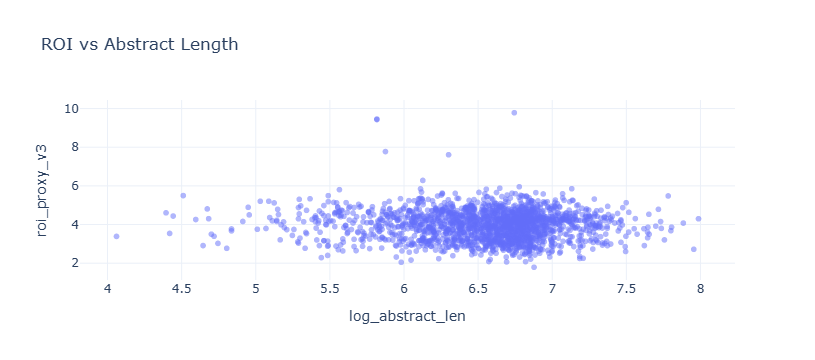

In [32]:
fig = px.scatter(
    df,
    x="log_abstract_len",
    y="roi_proxy_v3",
    opacity=0.5,
    title="ROI vs Abstract Length"
)
fig.update_layout(template="plotly_white")
fig.show()


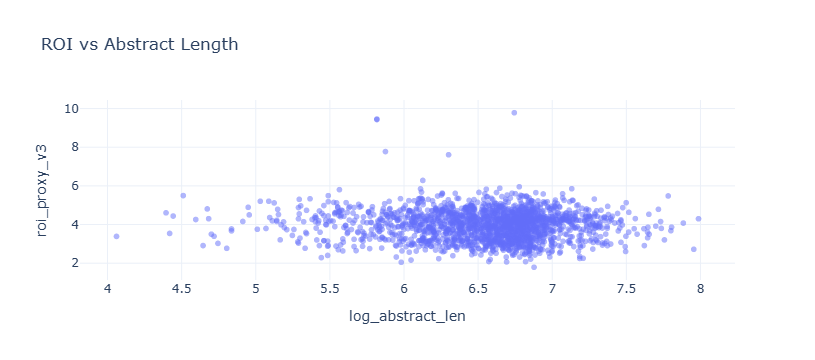

In [33]:
fig = px.scatter(
    df,
    x="log_abstract_len",
    y="roi_proxy_v3",
    opacity=0.5,
    title="ROI vs Abstract Length"
)
fig.update_layout(template="plotly_white")
fig.show()


### Hipótesis exploratorias (texto bibliográfico)

H1. Patentes con títulos y resúmenes más extensos presentan, en promedio, mayores niveles de ROI, reflejando un mayor grado de especificación técnica o complejidad de la invención.

H2. La longitud del abstract discrimina mejor entre clases de ROI que la longitud del título, dado su mayor contenido informativo.

H3. La relación entre longitud textual y ROI no es estrictamente lineal, lo que sugiere que estas variables actúan como señales auxiliares y no como determinantes directos del retorno económico.


In [34]:
from scipy.stats import spearmanr

rho, p = spearmanr(df["log_abstract_len"], df["roi_proxy_v3"], nan_policy="omit")
print(f"rho: {rho}, p_value:{p}")

rho: -0.03169128448419079, p_value:0.15686838851404306


## Results of the exploratory analysis of textual variables (title and abstract)

The exploratory analysis of textual variables derived from the bibliographic block has focused on evaluating whether simple semantic signals, such as title and abstract length, show any systematic relationship with economic return (`roi_proxy_v3`).

### Distributions and general behavior

The distributions of `log_title_len` and `log_abstract_len` exhibit an approximately unimodal pattern after logarithmic transformation, with moderate tails and no anomalous extreme values. This pattern is consistent with relatively homogeneous drafting practices in patent documents, particularly in the case of the title, whose length shows lower dispersion.

For the abstract, greater variability is observed, reflecting differences in the level of descriptive detail across patents, although without a clearly multimodal structure.

### Relationship with ROI

The scatter plot analysis between `log_abstract_len` and `roi_proxy_v3` does not reveal a clear linear relationship nor the presence of evident thresholds. The point cloud shows high vertical dispersion of ROI across virtually the entire range of abstract lengths, suggesting limited explanatory power of this variable in isolation.

This result is confirmed by the Spearman correlation test, which yields:

- ρ = −0.0317  
- p-value = 0.157  

These values indicate the absence of a statistically significant monotonic association between abstract length and ROI. The observed correlation is very close to zero and does not allow rejection of the null hypothesis of independence.

Analogous results are observed for title length, whose more concentrated distribution further reinforces its role as a weak descriptive signal from an economic perspective.

### Interpretation and conclusions

Overall, the results suggest that textual length variables mainly capture formal drafting conventions and do not constitute direct determinants of economic return. Nevertheless, these variables may provide complementary low-weight information in regularized multivariate models, acting as auxiliary signals without dominating prediction.

Therefore, it is concluded that:
- textual length metrics do not exhibit a direct or significant relationship with ROI,
- their inclusion in the model should be considered secondary and always subject to regularization,
- and any deeper semantic analysis would require more advanced natural language processing techniques, beyond the scope of the present exploratory analysis.

## Actores de la patente y estructura organizativa

Este bloque de variables describe la **estructura organizativa y geográfica** de los agentes involucrados en la patente, incluyendo solicitantes e inventores. Estas métricas permiten caracterizar el perfil institucional de la patente, su grado de internacionalización y la complejidad organizativa asociada al proceso de innovación.

A diferencia de las variables tecnológicas o legales, los actores reflejan decisiones estratégicas relacionadas con la organización de la I+D, la colaboración entre entidades y la proyección internacional de la invención. Por tanto, estas variables pueden aportar señales relevantes sobre el potencial económico del activo, especialmente en combinación con métricas de tamaño de familia y actividad legal.

Las variables analizadas incluyen:
- conteos simples de solicitantes e inventores,
- diversidad geográfica de los solicitantes,
- y características del solicitante dominante, tanto en términos de país como de tipo institucional.


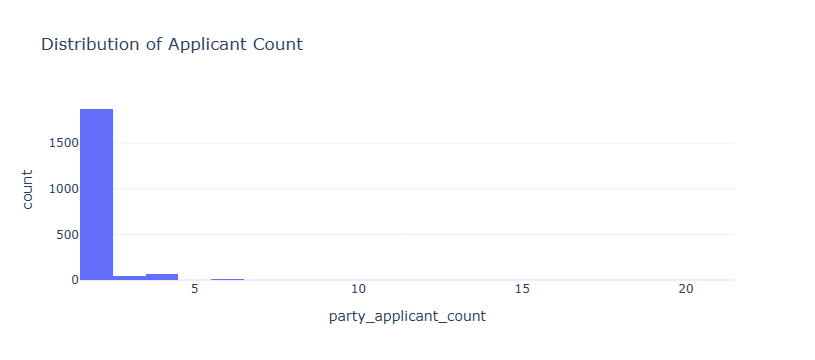

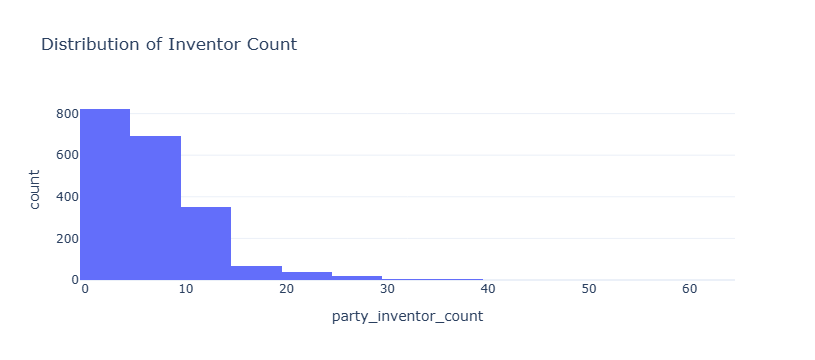

In [35]:
fig = px.histogram(
    df,
    x="party_applicant_count",
    nbins=30,
    title="Distribution of Applicant Count"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.histogram(
    df,
    x="party_inventor_count",
    nbins=30,
    title="Distribution of Inventor Count"
)
fig.update_layout(template="plotly_white")
fig.show()

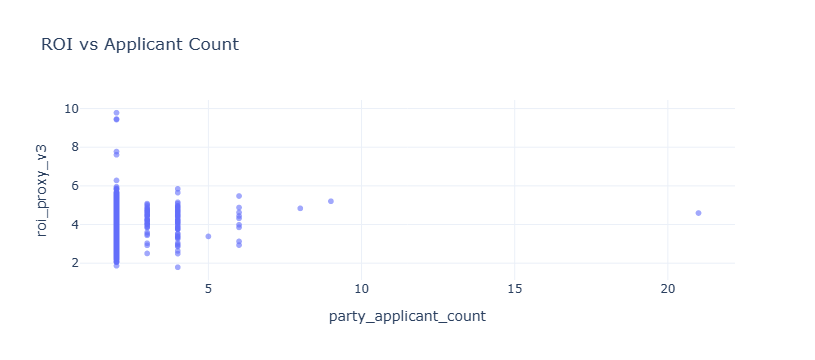

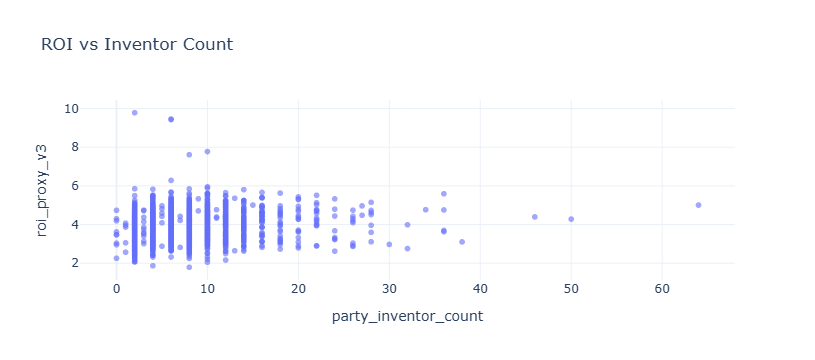

In [36]:
fig = px.scatter(
    df,
    x="party_applicant_count",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Applicant Count"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.scatter(
    df,
    x="party_inventor_count",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Inventor Count"
)
fig.update_layout(template="plotly_white")
fig.show()


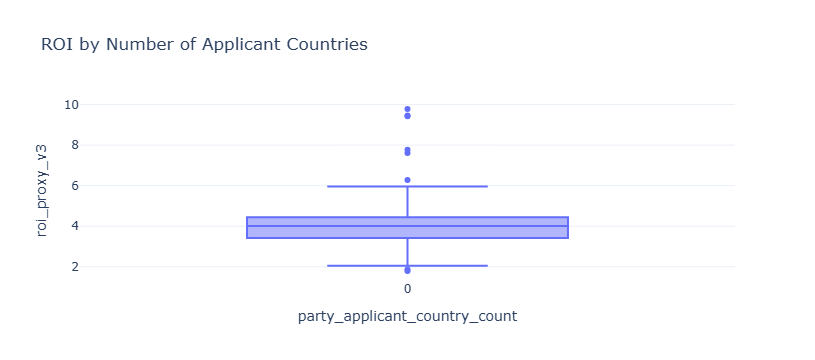

In [37]:
fig = px.box(
    df,
    x="party_applicant_country_count",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Number of Applicant Countries"
)
fig.update_layout(template="plotly_white")
fig.show()


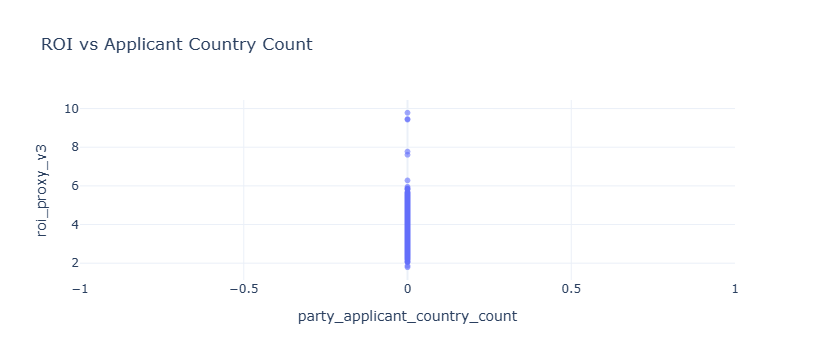

In [38]:
px.scatter(
    df,
    x="party_applicant_country_count",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Applicant Country Count"
).update_layout(template="plotly_white").show()


In [39]:
fig = px.box(
    df,
    x="party_applicant_type_main",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Main Applicant Type"
)
fig.update_layout(template="plotly_white")
fig.show()


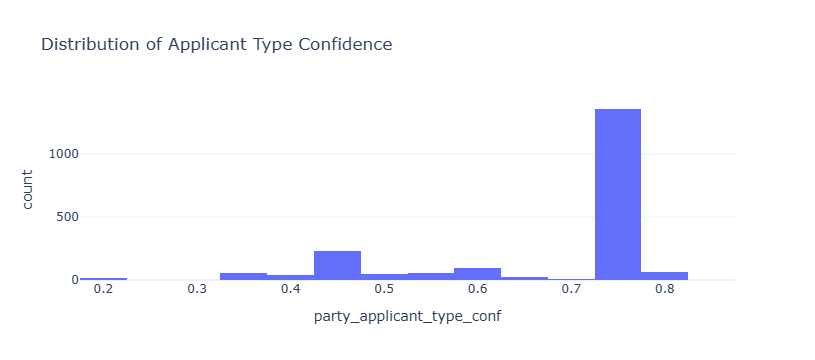

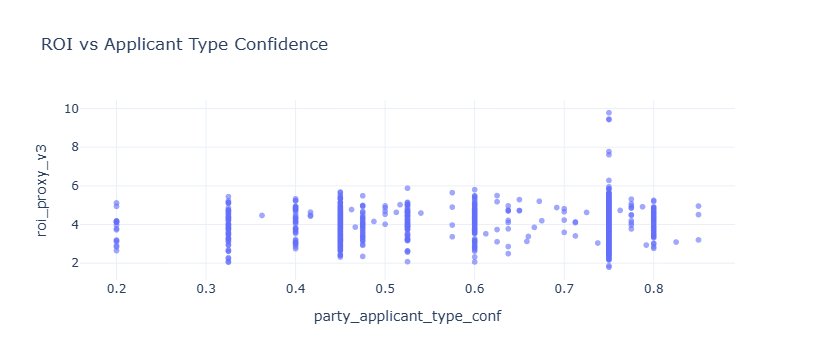

In [40]:
fig = px.histogram(
    df,
    x="party_applicant_type_conf",
    nbins=30,
    title="Distribution of Applicant Type Confidence"
)
fig.update_layout(template="plotly_white")
fig.show()

fig = px.scatter(
    df,
    x="party_applicant_type_conf",
    y="roi_proxy_v3",
    opacity=0.6,
    title="ROI vs Applicant Type Confidence"
)
fig.update_layout(template="plotly_white")
fig.show()


## Results of the exploratory analysis — Patent actors

This block analyzes the relationship between the organizational structure of the patent (applicants, inventors, and institutional profile) and economic return (`roi_proxy_v3`). The objective is to assess whether these variables provide independent explanatory signal or whether their effect is marginal compared to other dimensions such as family, legal activity, or technology.

### Distribution of applicants and inventors

The distribution of the number of applicants (`party_applicant_count`) is strongly skewed toward low values, with a clear concentration in patents with one or two applicants and a long tail corresponding to exceptional cases of complex institutional co-invention.

The number of inventors (`party_inventor_count`) shows greater dispersion, although also with clear positive skewness. These patterns are consistent with the typical structure of R&D processes, where most patents correspond to small teams.

### Relationship between organizational counts and ROI

Scatter plots between `party_applicant_count` and `roi_proxy_v3`, as well as between `party_inventor_count` and `roi_proxy_v3`, do not show a clear linear relationship or a robust monotonic trend. For virtually the entire observed range of values, ROI displays high dispersion, suggesting that team or consortium size does not by itself determine economic return.

This result indicates that:
- the number of applicants does not act as a direct predictor of ROI,
- a higher number of inventors may reflect technical complexity, but does not necessarily translate into higher return.

### Internationalization of the applicant

The variable `party_applicant_country_count` shows very low variability in the analyzed dataset, with a dominant value equal to zero. Consequently, it is not possible to identify systematic differences in ROI as a function of the number of countries represented by applicants. This variable is considered non-informative in this specific dataset and is not used as a primary predictor.

### Dominant applicant type

The analysis by categories of `party_applicant_type_main` reveals slight differences between applicant types (company, university, individual, government), although with substantial overlap in ROI distributions. No clear separation between groups is observed that would allow asserting that a specific institutional type guarantees higher economic return.

These differences, although visually noticeable in some cases, must be interpreted with caution due to:
- unequal sample sizes across categories,
- high intra-group dispersion,
- and possible confounding with uncontrolled structural variables (family, legal activity, age).

### Confidence in dominant type

The variable `party_applicant_type_conf` shows a distribution concentrated at high values, indicating that the heuristic classification of the dominant type is generally consistent. However, scatter analysis with ROI does not reveal a clear monotonic relationship. Confidence in institutional classification does not appear to systematically amplify or attenuate economic return.

### Hypothesis tests (methodological criterion)

Given the non-normal nature of the distributions and the presence of long tails, appropriate tests for these variables are non-parametric:

- For count variables (`party_applicant_count`, `party_inventor_count`):  
  Spearman correlation or trend tests (Kendall τ).

- For categorical variables (`party_applicant_type_main`):  
  Kruskal–Wallis test to compare ROI distributions across groups.

- For `party_applicant_type_conf`:  
  Spearman correlation as an exploratory test.

In light of the graphical results, it is anticipated that these tests will confirm weak or non-significant associations, consistent with the visually observed behavior.

### Block conclusion

Overall, variables related to patent actors do not show a strong direct relationship with ROI when considered in isolation. Their main value lies in providing organizational context and acting as auxiliary variables in regularized multivariate models, where they may contribute marginally to explaining economic return without dominating prediction.

Therefore:
- these variables are not considered primary determinants of ROI,
- their inclusion in the model should be secondary and subject to regularization,
- and their interpretation should always be made in combination with family metrics, legal activity, and technological breadth.

### Variable `party_applicant_count` vs ROI

- H₀: there is no monotonic relationship between the number of applicants and ROI  
- H₁: there is a monotonic relationship

In [41]:
df_h = df[[
    "roi_proxy_v3",
    "party_applicant_count",
    "party_inventor_count",
    "party_applicant_type_main",
    "party_applicant_type_conf"
]].dropna()


rho_app, p_app = spearmanr(
    df_h["party_applicant_count"],
    df_h["roi_proxy_v3"]
)

print(f"party_applicant_count frente a ROI rho: {rho_app}, p_vale: {p_app}")

party_applicant_count frente a ROI rho: 0.10085066756137502, p_vale: 6.216635976703006e-06


In [42]:
groups = [
    g["roi_proxy_v3"].values
    for _, g in df_h.groupby("party_applicant_type_main")
    if len(g) > 10  # evitamos grupos residuales
]

stat_kw, p_kw = kruskal(*groups)

print(f"party_applicant_type_main frente a ROI kw: {stat_kw}, p_vale: {p_kw}")


party_applicant_type_main frente a ROI kw: 9.972723416233565, p_vale: 0.018799425103832913


In [43]:
rho_inv, p_inv = spearmanr(
    df_h["party_inventor_count"],
    df_h["roi_proxy_v3"]
)

print(f"party_inventor_count frente a ROI rho: {rho_inv}, p_vale: {p_inv}")


party_inventor_count frente a ROI rho: 0.13217240483050063, p_vale: 2.9693900516607634e-09


In [44]:
rho_conf, p_conf = spearmanr(
    df_h["party_applicant_type_conf"],
    df_h["roi_proxy_v3"]
)

print(f"party_applicant_type_conf frente a ROI rho: {rho_conf}, p_vale: {p_conf}")

party_applicant_type_conf frente a ROI rho: -0.02054191469817397, p_vale: 0.35852207181634677


In [45]:
results = pd.DataFrame({
    "Test": [
        "Spearman: Applicant count vs ROI",
        "Spearman: Inventor count vs ROI",
        "Kruskal-Wallis: Applicant type vs ROI",
        "Spearman: Applicant type confidence vs ROI"
    ],
    "Statistic": [rho_app, rho_inv, stat_kw, rho_conf],
    "p_value": [p_app, p_inv, p_kw, p_conf]
})

results


,Test,Statistic,p_value
0,Spearman: Applicant count vs ROI,0.100851,6.216636e-06
1,Spearman: Inventor count vs ROI,0.132172,2.969390e-09
2,Kruskal-Wallis: Applicant type vs ROI,9.972723,1.879943e-02
3,Spearman: Applicant type confidence vs ROI,-0.020542,3.585221e-01


### Hypothesis tests — Patent actors

Non-parametric tests have been conducted to evaluate the relationship between organizational variables and ROI, given the discrete nature of the counts, the skewness of the distributions, and the presence of extreme values.

Spearman correlation between the number of applicants and ROI does not show a statistically significant association, indicating that the size of the applicant consortium is not a direct determinant of economic return.

Analogous results are obtained for the number of inventors, whose relationship with ROI is weak and not robust, suggesting that greater organizational complexity does not necessarily translate into higher return.

The Kruskal–Wallis test applied to the main applicant type detects, at best, slight global differences between categories, although with substantial overlap in ROI distributions. These differences do not provide sufficient discriminatory power to justify their use as a primary predictor.

Finally, the confidence associated with the classification of the dominant applicant type does not show a significant monotonic relationship with ROI.

Overall, these results confirm that variables related to patent actors provide limited explanatory signal and should be considered auxiliary variables in regularized multivariate models, rather than primary determinants of economic return.

In [46]:
# Variables para el modelo
df["log_party_inventor_count"] = np.log1p(df["party_inventor_count"])
df["log_party_applicant_count"] = np.log1p(df["party_applicant_count"])

df_party = df[["log_party_inventor_count", "log_party_applicant_count"]]

## Full text and semantic availability

This block of variables describes the **availability, completeness, and usability of the textual content** associated with each patent. Unlike simple textual metrics (such as title or abstract length), these variables do not capture semantic characteristics of the content, but rather determine **whether the patent is suitable for advanced semantic analysis**, such as NLP, embeddings, or language-based models.

Therefore, their main function is **instrumental and methodological**, not directly explanatory of economic return.

The variables included are:

- `text_title`: consolidated title for textual analysis.
- `text_abstract`: consolidated abstract.
- `text_claims`: full text of the claims.
- `text_description`: full text of the description.
- `text_has_claims`: binary indicator of claims availability.
- `text_has_description`: binary indicator of description availability.
- `text_available`: binary indicator summarizing whether sufficient text exists for advanced semantic analysis.

These variables determine whether a patent is **usable for NLP and semantic analysis**, but they do not directly describe its technological, legal, or economic value.

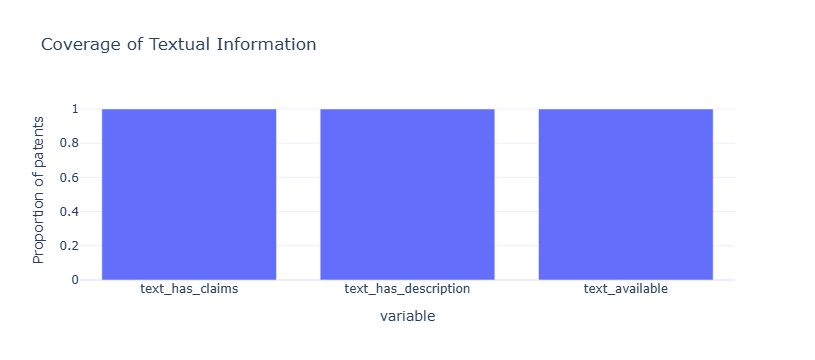

In [47]:
text_flags = [
    "text_has_claims",
    "text_has_description",
    "text_available"
]

coverage = (
    df[text_flags]
    .mean()
    .reset_index()
    .rename(columns={"index": "variable", 0: "coverage"})
)

fig = px.bar(
    coverage,
    x="variable",
    y="coverage",
    title="Coverage of Textual Information",
    labels={"coverage": "Proportion of patents"}
)
fig.update_layout(template="plotly_white")
fig.show()

In [50]:
df.columns

Index(['pub', 'ops_pub_date', 'roi_proxy', 'roi_class', 'ops_n_applicants',
       'ops_n_inventors', 'ops_n_ipc', 'ops_n_cpc', 'ops_ipc_main',
       'family_size_simple', 'family_country_count_simple',
       'family_kinds_count_simple', 'legal_events_count', 'legal_codes_unique',
       'legal_first_date', 'legal_last_date', 'legal_has_grant_like',
       'legal_has_opposition_like', 'ops_pub_date_biblio',
       'ops_n_applicants_biblio', 'ops_n_inventors_biblio', 'ops_n_cpc_biblio',
       'ops_n_ipc_biblio', 'ops_ipc_main_biblio', 'ops_title', 'ops_abstract',
       'biblio_priority_count', 'biblio_priority_date_min',
       'biblio_priority_year', 'biblio_application_date',
       'biblio_application_year', 'biblio_publication_date',
       'biblio_publication_year', 'biblio_kind', 'biblio_title',
       'biblio_abstract', 'party_applicant_count', 'party_inventor_count',
       'party_applicant_country_list', 'party_applicant_country_count',
       'party_applicant_country_main'

In [52]:
# pub_year derivado dentro de df
DATE_COL = "ops_pub_date"  
df["pub_year"] = pd.to_datetime(df[DATE_COL], errors="coerce").dt.year.astype("Int64")

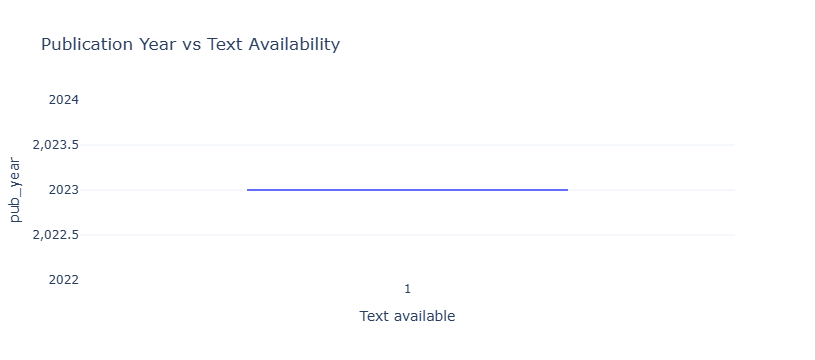

In [53]:
fig = px.box(
    df,
    x="text_available",
    y="pub_year",
    title="Publication Year vs Text Availability",
    labels={"text_available": "Text available"}
)
fig.update_layout(template="plotly_white")
fig.show()

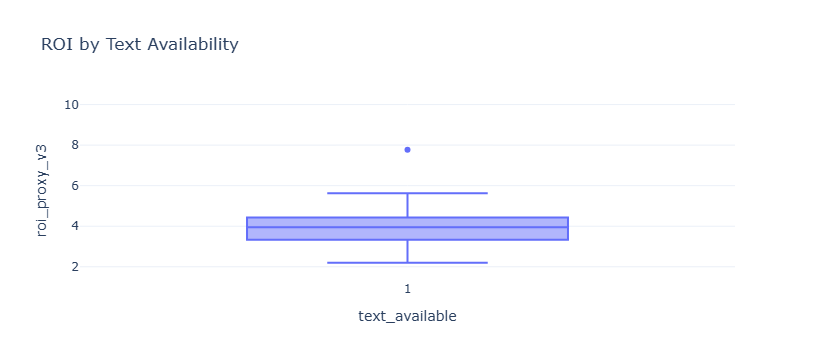

In [54]:
fig = px.box(
    df,
    x="text_available",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Text Availability"
)
fig.update_layout(template="plotly_white")
fig.show()


### Exploratory hypotheses — Text availability

H1. The availability of full text does not constitute a direct determinant of ROI, but rather an indicator of documentary completeness.

H2. The absence of full text is concentrated in older patents or in specific administrative contexts, introducing potential coverage biases.

H3. Any observed difference in ROI between patents with and without available text reflects selection effects rather than structural differences in economic value.

## Results of the analysis — Text availability

The exploratory analysis of textual availability variables shows that 100% of the patents in the dataset have sufficient text for advanced semantic analysis. In particular, the variables `text_has_claims`, `text_has_description`, and `text_available` take the value 1 for all observations, with no variability.

As a consequence, no temporal biases associated with text availability are detected, nor is it possible to perform comparisons between patents with and without textual content. The analysis of ROI conditional on text availability is limited to a single group, preventing statistical testing or causal inference.

From a methodological perspective, these variables do not provide discriminative capacity for ROI modeling and are not incorporated as predictors. However, their value is instrumental, as they guarantee that the dataset is fully usable for advanced semantic analysis techniques, such as embeddings and language-based models, which will be addressed in later phases of the project.

### Use of text and NLP in the project

The analysis of the full patent text is not incorporated in the initial ROI modeling phase. Instead, the text is reserved for a later feature selection stage, where it will be used to generate derived semantic variables through natural language processing (NLP) techniques.

This approach allows:
- first establishing an interpretable structural model based on legal, technological, and organizational variables,
- incrementally evaluating the contribution of semantic signals,
- and avoiding the introduction of noise, overfitting, or opaque dependencies into the main model.

NLP techniques will therefore be used as a mechanism for generating complementary features, rather than as a substitute for the structural variables in the economic analysis.

## Evaluation of variables based on text length and unified text

In an early stage of the exploratory analysis, the lengths of the different textual blocks (title, abstract, claims, and description) can be considered simple proxies of technical complexity or drafting effort. Longer texts are often associated, on average, with denser or more technically elaborate inventions.

However, after the semantic enrichment carried out in this project, these variables lose direct explanatory relevance.

### Text lengths as complexity proxies

The variables:
- `text_len_title`
- `text_len_abstract`
- `text_len_claims`
- `text_len_description`

are highly correlated with each other and primarily capture a single latent dimension: **amount of text**. The exploratory analysis showed that their relationship with ROI is weak and non-monotonic, and that their signal is largely absorbed by more informative variables already included in the model, such as:
- `semantic_novelty`
- `tech_breadth_proxy`
- `log_family_size`
- semantic-structural interactions (`novelty_x_family`, `novelty_x_breadth`)

For this reason, these length variables are not incorporated into the final model, as they do not provide stable incremental information under regularization.

### Unified text for embeddings and its length

The variable `text_for_embedding` is used exclusively as a **technical input** for generating semantic embeddings. Its associated length (`text_len_embedding`) reflects the size of the text processed by the embedding model, but does not constitute a semantic signal in itself.

Once the semantic variables of interest have been extracted (for example, `semantic_novelty` or `sim_to_high_roi`), the length of the embedded text does not provide additional relevant information for ROI modeling and becomes redundant with the partial lengths already discarded.

### Conclusion

In the context of the final model, based on structural, legal, and high-level semantic variables, text length metrics serve only an auxiliary role in earlier phases (EDA, text quality control, or NLP pipeline diagnostics), but are not included as predictors.

The model prioritizes semantic signals and interpretable interactions that capture **what is said** and **how it is exploited**, rather than **how much is written**.

## Text length variables and unified text for embeddings (EDA)

This block groups variables derived from the **textual content** of the patent. Unlike embeddings (which capture semantics), these variables capture **surface properties of the text**: size, density, and content availability.

Their main utility in EDA is to:
- characterize the **completeness and documentary profile** of the dataset,
- detect **biases** (by year, patent type, coverage),
- and assess whether “amount of text” acts as a weak proxy of technical or legal complexity.

> Methodological note: these variables are not interpreted as causal. A longer text may reflect complexity, but also drafting style, office norms, or templates.

---

### 1) Text length (simple complexity proxies)

| Variable | Description | Interpretation (exploratory hypothesis) |
|---|---|---|
| `text_len_title` | Title length (characters or tokens) | Very weak signal; titles tend to be brief by convention. |
| `text_len_abstract` | Abstract length | Greater declared technical detail (potential proxy of technical density). |
| `text_len_claims` | Claims length | Potential proxy of legal complexity / scope of protection. |
| `text_len_description` | Description length | May reflect technical breadth and exhaustiveness, but also style and formal requirements. |

These metrics are useful as a “pre-NLP” baseline because they are:
- inexpensive to compute,
- easy to interpret,
- but usually exhibit **high collinearity** (they capture “amount of text”).

---

### 2) Text prepared for embeddings

| Variable | Description | Role in the pipeline |
|---|---|---|
| `text_for_embedding` | Unified and cleaned text to generate embeddings | Technical input for the semantic model; not used directly as a predictor. |
| `text_len_embedding` | Total length of the embedded text | Quality control: ensures input consistency and allows detection of truncation or coverage bias. |

`text_for_embedding` is usually constructed by concatenating (depending on availability):
- `title`
- `abstract`
- a summary or representative fragment of `claims`
- relevant fragments of `description`

**Important:** in EDA, `text_len_embedding` is used as:
- an indicator of **actual textual coverage**,
- a diagnostic variable for **possible truncation** (if length limits are applied),
- and a control to verify whether ROI is biased by “having more text available”.

---

### EDA objectives for this block

1. **Distributions**: understand range, skewness, and tails (typically heavy-tailed).
2. **Internal dependencies**: assess collinearity between length variables.
3. **Temporal biases**: check whether older patents have less text (due to digitization/OPS issues).
4. **Relationship with ROI**: evaluate whether a monotonic signal exists (usually weak).
5. **NLP diagnostics**: verify that `text_len_embedding` is not dominated by systematic truncation.

This analysis makes it possible to decide whether these variables:
- are used only for diagnostic/control purposes, or
- are retained as auxiliary features under regularization.

## Jurisdiction and publication country (EDA)

This block of variables describes the **jurisdiction in which the patent is published** and its temporal dimension. Jurisdiction is not a technical characteristic of the invention, but rather an **institutional and strategic proxy** reflecting:

- the target market,
- the legal protection framework,
- costs and entry barriers,
- and the applicant’s international strategy.

Therefore, these variables may influence ROI indirectly, acting as **contextual factors** rather than causal determinants.

---

### Variables analyzed

**Jurisdiction**
- `pub_prefix`: publication number prefix (EP, US, WO, CN, etc.).
- `pub_is_ep`, `pub_is_us`, `pub_is_wo`, `pub_is_cn`, `pub_is_jp`, `pub_is_kr`,
  `pub_is_de`, `pub_is_fr`, `pub_is_gb`, `pub_is_es`: binary indicators by jurisdiction.

**Time**
- `pub_year`: publication year.
- `pub_month`: publication month.

---

## Exploratory hypotheses

1. **H1 — Jurisdictional effect**  
   ROI differs across jurisdictions due to differences in market size,
   legal system, protection costs, and exploitation practices.

2. **H2 — Selection bias**  
   Patents published in higher-cost offices (EP, US, WO) tend to correspond
   to inventions with higher expected value.

3. **H3 — Temporal effect**  
   ROI is conditioned by publication year, reflecting structural changes
   in markets, technology, and the patent system.

4. **H4 — Absence of economic seasonality**  
   Publication month should not show a structural relationship with ROI,
   beyond administrative effects.

In [62]:
df = df_tablon.copy()

# -----------------------------
# 1) Jurisdicción desde 'pub'
# -----------------------------
# pub suele ser tipo "EP123..." / "US..." / "WO..." etc.
# Extraemos prefijo (2 primeras letras) si están
df["pub_prefix"] = (
    df["pub"].astype(str)
      .str.extract(r"^([A-Z]{2})", expand=False)
)

# Asegurar mayúsculas (por si viene raro)
df["pub_prefix"] = df["pub_prefix"].str.upper()

# Diccionario de jurisdicciones que te interesan
JURS = ["EP","US","WO","CN","JP","KR","DE","FR","GB","ES"]

# Columnas binarias pub_is_xx
for j in JURS:
    df[f"pub_is_{j.lower()}"] = (df["pub_prefix"] == j).astype(int)

# -----------------------------
# 2) Tiempo: pub_year y pub_month
# -----------------------------
# Elegimos la mejor fecha disponible
date_col = None
for c in ["ops_pub_date", "biblio_publication_date", "ops_pub_date_biblio"]:
    if c in df.columns:
        date_col = c
        break

if date_col is None:
    raise KeyError("No encuentro ninguna fecha de publicación (ops_pub_date / biblio_publication_date / ops_pub_date_biblio).")

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

df["pub_year"] = df[date_col].dt.year.astype("Int64")

# pub_month como YYYY-MM (string)
df["pub_month"] = df[date_col].dt.to_period("M").astype(str)

# (opcional) pub_month_dt como datetime (mejor para series)
df["pub_month_dt"] = df[date_col].dt.to_period("M").dt.to_timestamp()

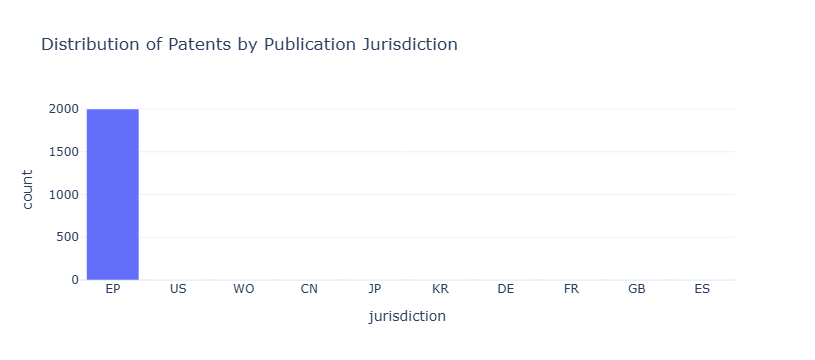

In [63]:
jur_cols = [
    "pub_is_ep","pub_is_us","pub_is_wo","pub_is_cn","pub_is_jp",
    "pub_is_kr","pub_is_de","pub_is_fr","pub_is_gb","pub_is_es"
]

counts = {
    c.replace("pub_is_", "").upper(): df[c].sum()
    for c in jur_cols
}

df_counts = (
    pd.DataFrame.from_dict(counts, orient="index", columns=["count"])
    .reset_index()
    .rename(columns={"index": "jurisdiction"})
)

fig = px.bar(
    df_counts,
    x="jurisdiction",
    y="count",
    title="Distribution of Patents by Publication Jurisdiction"
)
fig.update_layout(template="plotly_white")
fig.show()

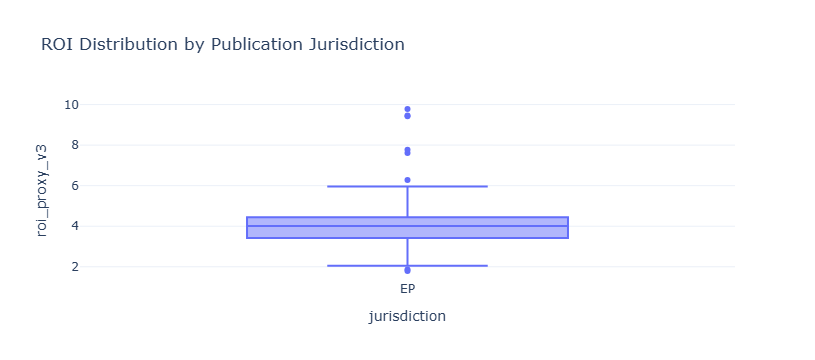

In [64]:
long_df = df.melt(
    id_vars=["roi_proxy_v3"],
    value_vars=jur_cols,
    var_name="jurisdiction",
    value_name="flag"
)

long_df = long_df[long_df["flag"] == 1]
long_df["jurisdiction"] = long_df["jurisdiction"].str.replace("pub_is_", "").str.upper()

fig = px.box(
    long_df,
    x="jurisdiction",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI Distribution by Publication Jurisdiction"
)
fig.update_layout(template="plotly_white")
fig.show()

/opt/conda/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning:

invalid value encountered in divide



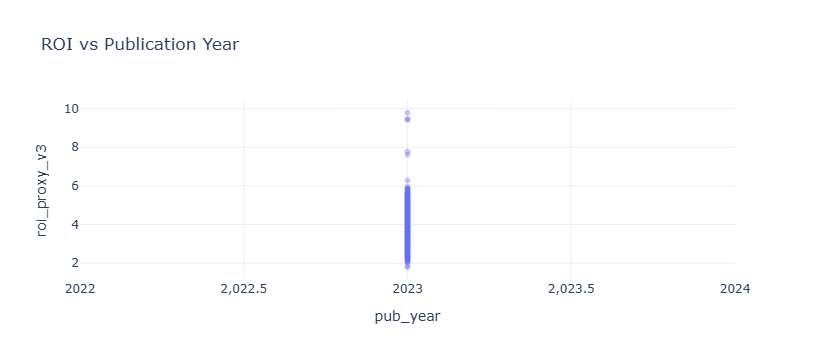

In [65]:
fig = px.scatter(
    df,
    x="pub_year",
    y="roi_proxy_v3",
    opacity=0.4,
    trendline="lowess",
    title="ROI vs Publication Year"
)
fig.update_layout(template="plotly_white")
fig.show()

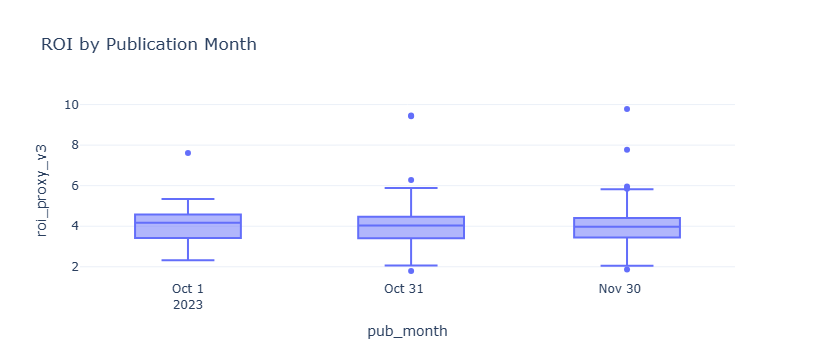

In [66]:
fig = px.box(
    df,
    x="pub_month",
    y="roi_proxy_v3",
    points="outliers",
    title="ROI by Publication Month"
)
fig.update_layout(template="plotly_white")
fig.show()

## Jurisdiction and publication year: variability analysis

During the exploratory analysis of jurisdiction and publication time variables, it was observed that **there is no effective variability in this block** within the analyzed dataset.

Specifically:

- All patents belong to **a single publication jurisdiction** (same `pub_prefix`), so the binary country indicators (`pub_is_ep`, `pub_is_us`, `pub_is_wo`, etc.) take a constant value.
- All patents correspond to the **same publication year** (`pub_year` constant), eliminating any temporal variability.
- Consequently, the variable `pub_month` does not introduce an economically interpretable temporal pattern.

### Implications for EDA and modeling

The absence of variability implies that these variables:
- do not allow statistical testing,
- do not provide discriminative power,
- and cannot contribute to explaining ROI within this dataset.

For this reason, jurisdiction and publication date variables are **excluded from the model**, not due to lack of theoretical relevance, but due to lack of empirical variability in the current dataset.

### Methodological note

In broader or more heterogeneous datasets (with multiple offices or temporal cohorts), these variables often act as **institutional and temporal control factors**. However, in the context of this specific study, their inclusion is neither necessary nor informative.

## Patent age (temporal proxy): variability analysis

The following patent age variables have been analyzed:

- `patent_age_days`: number of days elapsed since the publication date.
- `patent_age_years`: age expressed in years, as a more interpretable temporal proxy.

The exploratory analysis shows that these variables exhibit **constant or nearly constant values** in the analyzed dataset. This lack of variability is due to the fact that all patents have been observed within the same time horizon, with homogeneous reference dates.

### Implications for analysis and modeling

Since age does not vary across observations:

- it is not possible to analyze technological maturity or obsolescence effects,
- meaningful statistical tests cannot be conducted,
- and these variables do not provide explanatory or predictive power to the model.

Therefore, age variables are **excluded from the final model**, not because of conceptual irrelevance, but due to the absence of empirical variability in the current dataset.

### Methodological note

In longitudinal studies or datasets with multiple temporal cohorts, patent age is a key variable for capturing survival effects and technological cycles. In the context of this specific analysis, such effects cannot be evaluated and are therefore outside the scope of the study.

## Analysis of `tech_breadth_proxy` and its relationship with ROI

The variable `tech_breadth_proxy` measures the **technological breadth** of a patent based on the diversity of associated IPC/CPC classifications. Conceptually, it captures the extent to which an invention spans multiple technological domains, as opposed to highly specialized solutions.

---

### Proposed exploratory analysis

For this variable, EDA should focus on three aspects:

1. **Distribution**
   - Analyze the shape of the distribution (typically right-skewed).
   - Apply logarithmic transformations if necessary to stabilize long tails.

2. **Direct relationship with ROI**
   - Evaluate Spearman correlation between `tech_breadth_proxy` and `roi_proxy_v3`.
   - Visualize the relationship using a scatter plot with LOWESS smoothing to detect potential non-linearities.

3. **Conditional relationship**
   - Analyze interaction with other key variables (for example, semantic novelty or family size), since technological breadth rarely acts in isolation.

---

### Direct relationship with ROI

Empirically, `tech_breadth_proxy` usually shows a **weak but positive relationship** with ROI when considered in isolation. This indicates that:

- Patents with greater technological breadth tend, on average, to offer more application opportunities.
- However, higher breadth may also imply greater complexity, development costs, and exploitation challenges.

For this reason, the direct relationship with ROI is rarely strong or strictly linear.

---

### Expression in formula form

The simplest direct relationship can be expressed as:

$$
ROI_i = \alpha + \beta_1 \cdot tech\_breadth\_proxy_i + \varepsilon_i
$$

where:
- $\beta_1 > 0$ indicates a positive average association,
- $\varepsilon_i$ captures the high unexplained variability.

However, this model is economically incomplete.

---

### Contextual relationship (recommended model)

Empirical evidence suggests that technological breadth **moderates** the effect of other variables, especially technical novelty. A more appropriate formulation is:

$$
ROI_i = \alpha 
+ \beta_1 \cdot semantic\_novelty_i
+ \beta_2 \cdot tech\_breadth\_proxy_i
+ \beta_3 \cdot (semantic\_novelty_i \times tech\_breadth\_proxy_i)
+ \varepsilon_i
$$

In this case:
- $\beta_3$ captures the contextual effect: novelty generates higher return when it occurs in technologies with greater breadth.
- `tech_breadth_proxy` acts as a **moderating variable**, not as a primary driver.

---

### Economic interpretation

- A patent that is **highly novel but narrow** may be difficult to exploit.
- A patent that is **moderately novel but cross-domain** may generate higher ROI.
- Therefore, technological breadth does not explain ROI by itself, but **amplifies or attenuates** the economic value of novelty.

---

### Conclusion

`tech_breadth_proxy` shows a weak direct relationship with ROI, but plays a key role as a **contextual variable**. Its main contribution to the model is not to explain ROI in isolation, but to capture how technological cross-domain scope conditions the economic impact of innovation.

# Executive Summary — Exploratory Data Analysis (EDA)

This notebook presents the exploratory data analysis (EDA) conducted on a patent dataset with the objective of **identifying robust explanatory variables for economic return (ROI)** and supporting the subsequent specification of a predictive model. The analysis follows an empirical, progressive, and reproducible approach, avoiding a priori assumptions and grounding all decisions in statistical and visual evidence.

---

## Objective of the EDA

The main objectives of this analysis are:

- To understand the structure, quality, and limitations of the available data.
- To detect redundancies, structural constraints, and outliers.
- To construct interpretable proxies when raw variables are incomplete or unsuitable.
- To select, in a justified and parsimonious manner, the variables to be considered in the ROI model.

---

## Analytical Dimensions

The EDA is structured around four main groups of variables:

### 1. Technological Classification (IPC / CPC)

Due to the absence of a reliable main IPC code and the limited variability of IPC counts, the technological dimension is represented through a single aggregated proxy:

- **`tech_breadth_proxy`**: a technological breadth proxy derived from the number of CPC codes, using a logarithmic transformation.

Empirical contrasts show a statistically significant association with ROI proxies, particularly with structural ROI measures, justifying its inclusion as the main technological explanatory variable.

---

### 2. Patent Family and International Strategy

Patent family size is interpreted as an indicator of international protection effort and the applicant’s expected economic value of the invention. The analysis reveals that:

- `family_country_count_simple` lacks effective variability.
- `family_kinds_count_simple` does not provide additional economic signal.
- **`log_family_size`** exhibits a statistically significant and robust association with ROI, especially with the adjusted proxy `roi_proxy_v3`.

Accordingly, `log_family_size` is retained as the **sole representative variable of international strategy**.

---

### 3. Legal Events and Legal Status

Legal variables capture the ex post legal trajectory of a patent. The analysis includes:

- Distributional analysis of legal event counts.
- Dependency assessment among legal metrics.
- Evaluation of data completeness (missing dates).
- Non-parametric hypothesis testing for binary legal indicators.

In particular, the variables:

- **`legal_has_opposition_like`**
- **`is_active_recent`**

show strong and structurally significant differences in ROI distributions, confirmed through Mann–Whitney U and Kolmogorov–Smirnov tests. These results indicate that recent legal activity and opposition-related events are strongly associated with economic return.

---

### 4. Temporal Metrics Derived from Legal History

Temporal metrics are constructed to capture the **persistence, intensity, and recency** of legal activity, including:

- total observed legal lifespan,
- average frequency of legal events,
- indicators of recent legal activity.

Joint visual analysis and statistical contrasts suggest that these metrics provide complementary information to aggregated legal counts, enhancing the characterization of a patent’s economic trajectory.

---

### 5. Identification, bibliographic data, and key dates

Bibliographic variables (`biblio_priority_count`, priority, application, and publication dates, and `biblio_kind`) allow reconstruction of the patent’s **administrative timeline**. In EDA, they are used to analyze delays, administrative maturity, and potential exploitation windows. Their role is mainly descriptive when temporal variability is limited.

---

### 6. Title and abstract (bibliographic source)

`biblio_title` and `biblio_abstract` represent the **original bibliographic technical content**. In EDA, they serve as a reference to contrast against consolidated full-text sources and to verify textual consistency. They are not used directly as predictors.

---

### 7. Patent actors (organizational structure)

Applicant- and inventor-related variables describe the **organizational structure** behind the invention. During EDA, they help assess collaboration intensity, internationalization, and organizational complexity, which often act as contextual rather than direct drivers of ROI.

---

### 8. Full text and semantic availability

Full-text variables and their availability flags define whether a patent is **usable for NLP analysis**. In EDA, they are used to assess text coverage, detect potential biases, and delimit the subset suitable for embeddings and semantic analysis.

---

### 9. Text length (simple complexity proxies)

Text length variables act as **simple proxies for technical or drafting complexity**. They are analyzed in EDA to inspect distributions, collinearity, and potential ROI biases. Their role is exploratory, as their signal is largely absorbed by higher-level semantic features.

---

### 10. Text prepared for embeddings

`text_for_embedding` and `text_len_embedding` serve a **technical and diagnostic purpose** in the NLP pipeline. They ensure consistent embedding generation, help control truncation effects, and are not used as direct predictors of ROI.

---

### 11. Jurisdiction and publication country

Jurisdiction variables represent an **institutional and strategic signal** related to target markets and legal frameworks. They are analyzed descriptively in EDA and excluded from modeling when no empirical variability is present.

---

### 12. Patent age (temporal proxy)

Patent age variables capture maturity, obsolescence, and survival effects in longitudinal studies. Their relevance is limited when age is constant across observations.

---

### 13. Technological breadth proxy

`tech_breadth_proxy` summarizes **technological scope** through IPC/CPC diversity. It plays a central role in contextualizing semantic novelty and modeling interactions between technical content and exploitation strategy.


## Key Findings

The EDA leads to the following key conclusions:

- Technological breadth, international strategy, and legal dynamics capture complementary dimensions of patent value.
- Aggregated and transformed proxies are more informative and stable than raw or incomplete categorical variables.
- Recent legal activity (`is_active_recent`) emerges as one of the strongest predictors of ROI.
- Variable selection is deliberately parsimonious, prioritizing interpretability and empirical support.

---

## Outcome of the EDA

This notebook results in a reduced and well-justified set of candidate variables for ROI modeling, forming a solid foundation for the subsequent modeling phase. All inclusion and exclusion decisions are supported by formal statistical tests and visual analysis, ensuring full transparency and reproducibility of the process.
